# Phase 3 : feature preparation

In [5]:
# ============================================================
# 1. IMPORT REQUIRED LIBRARIES
# ============================================================

from pathlib import Path

import numpy as np
import pandas as pd

from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# Display all dataframe columns
pd.set_option("display.max_columns", None)

# Fix the random state so results remain reproducible
RANDOM_STATE = 42

In [6]:
# ============================================================
# 2. LOAD THE FINAL DATASET
# ============================================================
# Change the path according to the location of your CSV file.

DATA_PATH = Path("../data/processed/dataset_labelled_with_score.csv")

# Example path for the uploaded dataset:
# DATA_PATH = Path("/mnt/data/dataset_labelled_with_score(2).csv")

# Check whether the dataset exists
if not DATA_PATH.exists():
    raise FileNotFoundError(
        f"Dataset not found at: {DATA_PATH.resolve()}\n"
        "Please update DATA_PATH with the correct file location."
    )

# Read the CSV dataset
df = pd.read_csv(DATA_PATH)

print("Dataset loaded successfully.")
print("Dataset shape:", df.shape)

df.head()

Dataset loaded successfully.
Dataset shape: (4172, 60)


,bank_count_500m,bus_stop_count_500m,cinema_count_500m,clinic_count_500m,college_count_500m,hospital_count_500m,museum_count_500m,office_count_500m,parking_space_count_500m,recreation_count_500m,retail_count_500m,school_count_500m,temple_count_500m,competitor_count_500m,avg_restaurant_rating_500m,avg_review_ratings_500m,nearest_restaurant_m,place_id,latitude,longitude,search_area,primary_type,searched_as,label,office_count_500m_normalized,retail_count_500m_normalized,bank_count_500m_normalized,commercial_score,bus_stop_count_500m_normalized,parking_space_count_500m_normalized,accessibility_score,college_count_500m_normalized,school_count_500m_normalized,education_score,hospital_count_500m_normalized,clinic_count_500m_normalized,health_activity_score,recreation_count_500m_normalized,cinema_count_500m_normalized,museum_count_500m_normalized,attraction_score,temple_count_500m_normalized,cultural_activity_score,nearest_restaurant_m_normalized,market_gap_score,competitor_count_500m_normalized,avg_restaurant_rating_500m_normalized,avg_review_ratings_500m_normalized,competition_pressure_score,commercial_score_contribution,accessibility_score_contribution,education_score_contribution,health_activity_score_contribution,attraction_score_contribution,cultural_activity_score_contribution,market_gap_score_contribution,competition_pressure_score_contribution,feasibility_score,cluster,feasibility_label
0,26,1,0,44,22,9,1,54,5,21,52,35,15,20,4.265000,87.700000,66.357920,ChIJsZ5mY70Z6zkRRBczgL9a8ms,27.699546,85.337687,Baneshwor,restaurant,restaurant,1,0.524272,0.329114,0.273684,0.375690,0.090909,0.217391,0.154150,0.343750,0.583333,0.463542,0.290323,0.578947,0.434635,0.272727,0.000000,0.027778,0.100168,0.144231,0.144231,0.015377,0.015377,0.837398,0.183750,0.941020,0.654056,0.034784,0.024980,0.046172,0.049802,0.016245,0.029305,0.002476,0.003158,20.692160,2,Moderate
1,43,4,1,46,37,13,1,66,6,16,80,40,13,44,4.247727,159.477273,3.883478,ChIJ5SO0EQ0Z6zkRTMnqUebrTqA,27.692262,85.336472,Baneshwor,restaurant,restaurant,1,0.640777,0.506329,0.452632,0.533246,0.363636,0.260870,0.312253,0.578125,0.666667,0.622396,0.419355,0.605263,0.512309,0.207792,0.142857,0.027778,0.126142,0.125000,0.125000,0.000900,0.000900,0.642276,0.188068,0.892192,0.574179,0.049372,0.050601,0.061995,0.058702,0.020457,0.025398,0.000145,0.002772,26.944194,0,High
2,57,6,3,65,49,12,1,68,9,15,66,28,6,48,4.231250,201.104167,35.022157,ChIJTdMmLgAZ6zkR84zXOWwdgPE,27.689064,85.334295,Baneshwor,restaurant,restaurant,1,0.660194,0.417722,0.600000,0.559305,0.545455,0.391304,0.468379,0.765625,0.466667,0.616146,0.387097,0.855263,0.621180,0.194805,0.428571,0.027778,0.217051,0.057692,0.057692,0.008116,0.008116,0.609756,0.192187,0.863875,0.555273,0.051785,0.075902,0.061373,0.071177,0.035200,0.011722,0.001307,0.002681,31.114502,0,High
3,5,0,0,23,6,4,0,66,4,26,78,16,17,14,4.371429,83.214286,5.217717,ChIJ3Ru72S8Z6zkR6JYG3tsYlGk,27.681549,85.341340,Baneshwor,restaurant,restaurant,1,0.640777,0.493671,0.052632,0.395693,0.000000,0.173913,0.086957,0.093750,0.266667,0.180208,0.129032,0.302632,0.215832,0.337662,0.000000,0.000000,0.112554,0.163462,0.163462,0.001209,0.001209,0.886179,0.157143,0.944072,0.662465,0.036636,0.014091,0.017950,0.024731,0.018253,0.033213,0.000195,0.003198,14.826712,2,Moderate
4,55,6,3,66,46,11,1,65,10,15,64,27,7,47,4.270213,200.893617,35.022157,ChIJJbL_SlQZ6zkRFWSjunPmuVU,27.688812,85.334080,Baneshwor,restaurant,restaurant,1,0.631068,0.405063,0.578947,0.538360,0.545455,0.434783,0.490119,0.718750,0.450000,0.584375,0.354839,0.868421,0.611630,0.194805,0.428571,0.027778,0.217051,0.067308,0.067308,0.008116,0.008116,0.617886,0.182447,0.864018,0.554784,0.049845,0.079425,0.058208,0.070083,0.035200,0.013676,0.001307,0.002678,31.042100,0,High


In [7]:

# ============================================================
# 3. DEFINE THE GROUP-LEVEL MODEL FEATURES
# ============================================================
# The original raw location indicators were normalized and
# combined into meaningful group-level features before applying
# the Entropy Weight Method (EWM).
#
# These eight group-level features were used to calculate the
# feasibility score and generate the feasibility labels.
#
# Therefore, the ML model uses these group-level features as
# its numerical input features.
#
# The following columns must not be used as model inputs:
# - feasibility_score
# - feasibility_label
# - cluster
# - EWM contribution columns
# - individual normalized columns
#
# This helps prevent data leakage.

NUMERIC_FEATURES = [
    "commercial_score",
    "accessibility_score",
    "education_score",
    "health_activity_score",
    "attraction_score",
    "cultural_activity_score",
    "market_gap_score",
    "competition_pressure_score",
]

# search_area is a categorical feature because it contains
# area names such as Baneshwor or New Road.
CATEGORICAL_FEATURES = [
    "search_area"
]

# Combine numerical and categorical features.
MODEL_FEATURES = (
    NUMERIC_FEATURES
    + CATEGORICAL_FEATURES
)

# Define the target variable.
TARGET_COLUMN = (
    "feasibility_label"
)

# Display the selected features.
print(
    "Number of numerical features:",
    len(NUMERIC_FEATURES)
)

print(
    "Number of categorical features:",
    len(CATEGORICAL_FEATURES)
)

print(
    "Total selected features:",
    len(MODEL_FEATURES)
)

print(
    "\nNumerical features:"
)

for feature in NUMERIC_FEATURES:
    print("-", feature)

print(
    "\nCategorical features:"
)

for feature in CATEGORICAL_FEATURES:
    print("-", feature)

print(
    "\nTarget column:",
    TARGET_COLUMN
)



Number of numerical features: 8
Number of categorical features: 1
Total selected features: 9

Numerical features:
- commercial_score
- accessibility_score
- education_score
- health_activity_score
- attraction_score
- cultural_activity_score
- market_gap_score
- competition_pressure_score

Categorical features:
- search_area

Target column: feasibility_label


In [8]:
# ============================================================
# 4. VALIDATE REQUIRED COLUMNS
# ============================================================
# This step checks whether all selected features and the target
# column are available in the dataset.

required_columns = MODEL_FEATURES + [TARGET_COLUMN]

missing_columns = [
    column
    for column in required_columns
    if column not in df.columns
]

if missing_columns:
    raise ValueError(
        "The following required columns are missing:\n"
        + "\n".join(f"- {column}" for column in missing_columns)
    )

print("All required feature and target columns are available.")

All required feature and target columns are available.


In [9]:
# ============================================================
# 5. SELECT THE RAW 500-METER FEATURES
# ============================================================
# X represents the input feature matrix.
#
# Only the selected raw location-based features are copied
# from the original dataset.

X = df[MODEL_FEATURES].copy()

print("Selected input features:")
print(X.columns.tolist())

print("\nFeature matrix shape:", X.shape)

X.head()

Selected input features:
['commercial_score', 'accessibility_score', 'education_score', 'health_activity_score', 'attraction_score', 'cultural_activity_score', 'market_gap_score', 'competition_pressure_score', 'search_area']

Feature matrix shape: (4172, 9)


,commercial_score,accessibility_score,education_score,health_activity_score,attraction_score,cultural_activity_score,market_gap_score,competition_pressure_score,search_area
0,0.375690,0.154150,0.463542,0.434635,0.100168,0.144231,0.015377,0.654056,Baneshwor
1,0.533246,0.312253,0.622396,0.512309,0.126142,0.125000,0.000900,0.574179,Baneshwor
2,0.559305,0.468379,0.616146,0.621180,0.217051,0.057692,0.008116,0.555273,Baneshwor
3,0.395693,0.086957,0.180208,0.215832,0.112554,0.163462,0.001209,0.662465,Baneshwor
4,0.538360,0.490119,0.584375,0.611630,0.217051,0.067308,0.008116,0.554784,Baneshwor


In [10]:
# ============================================================
# 6. IDENTIFY EXCLUDED COLUMNS
# ============================================================
# These columns should not be used for model training.
#
# Reasons for exclusion:
# - feasibility_score was used to generate the target label
# - cluster is an output from clustering
# - normalized columns are already transformed versions
# - contribution columns are part of the EWM calculation
# - place_id and restaurant_name are identifiers
#
# Including these columns could cause data leakage.

excluded_columns = [
    column
    for column in df.columns
    if (
        column in {
            "feasibility_score",
            "cluster",
            "label",
            "place_id",
            "restaurant_name",
            "address",
        }
        or column.endswith("_normalized")
        or column.endswith("_contribution")
    )
]

print("Excluded columns:")
for column in excluded_columns:
    print(column)

Excluded columns:
place_id
label
office_count_500m_normalized
retail_count_500m_normalized
bank_count_500m_normalized
bus_stop_count_500m_normalized
parking_space_count_500m_normalized
college_count_500m_normalized
school_count_500m_normalized
hospital_count_500m_normalized
clinic_count_500m_normalized
recreation_count_500m_normalized
cinema_count_500m_normalized
museum_count_500m_normalized
temple_count_500m_normalized
nearest_restaurant_m_normalized
competitor_count_500m_normalized
avg_restaurant_rating_500m_normalized
avg_review_ratings_500m_normalized
commercial_score_contribution
accessibility_score_contribution
education_score_contribution
health_activity_score_contribution
attraction_score_contribution
cultural_activity_score_contribution
market_gap_score_contribution
competition_pressure_score_contribution
feasibility_score
cluster


In [11]:
# ============================================================
# 7. VERIFY THAT LEAKAGE COLUMNS ARE NOT IN X
# ============================================================
# Assertions stop the notebook if a leakage column is
# accidentally included in the feature matrix.

assert "feasibility_score" not in X.columns
assert "cluster" not in X.columns
assert "label" not in X.columns
assert "place_id" not in X.columns

assert not any(
    column.endswith("_normalized")
    for column in X.columns
)

assert not any(
    column.endswith("_contribution")
    for column in X.columns
)

print("Data leakage checks passed.")

Data leakage checks passed.


In [12]:
# ============================================================
# 8. PREPARE THE TARGET COLUMN
# ============================================================
# The feasibility label is used as the prediction target.
#
# Text values are cleaned by:
# - converting to string
# - removing extra spaces
# - converting labels to title case

target_text = (
    df[TARGET_COLUMN]
    .astype("string")
    .str.strip()
    .str.title()
)

print("Unique feasibility labels:")
print(target_text.unique())

Unique feasibility labels:
<StringArray>
['Moderate', 'High', 'Low']
Length: 3, dtype: string


In [13]:
# ============================================================
# 9. VALIDATE THE FEASIBILITY LABELS
# ============================================================
# The dataset should contain only:
# Low, Moderate and High.

valid_labels = {
    "Low",
    "Moderate",
    "High"
}

actual_labels = set(
    target_text.dropna().unique()
)

invalid_labels = actual_labels - valid_labels

if invalid_labels:
    raise ValueError(
        f"Invalid feasibility labels found: {invalid_labels}"
    )

if target_text.isna().any():
    missing_target_count = target_text.isna().sum()

    raise ValueError(
        f"{missing_target_count} target values are missing."
    )

print("Feasibility labels are valid.")

Feasibility labels are valid.


In [14]:
# ============================================================
# 10. ENCODE THE TARGET LABELS
# ============================================================
# Machine learning models require numerical target values.
#
# Encoding:
# Low      = 0
# Moderate = 1
# High     = 2

LABEL_MAPPING = {
    "Low": 0,
    "Moderate": 1,
    "High": 2,
}

# Reverse mapping will later convert numerical predictions
# back into readable class names.
INVERSE_LABEL_MAPPING = {
    0: "Low",
    1: "Moderate",
    2: "High",
}

# Encode the target
y = target_text.map(LABEL_MAPPING).astype("int64")

print("Target encoding completed.")
print(y.head())

Target encoding completed.
0    1
1    2
2    2
3    1
4    2
Name: feasibility_label, dtype: int64


In [15]:
# ============================================================
# 11. DISPLAY THE TARGET DISTRIBUTION
# ============================================================
# This table shows the number and percentage of observations
# belonging to each feasibility class.

target_distribution = pd.DataFrame({
    "count": target_text.value_counts(),
    "percentage": (
        target_text.value_counts(normalize=True) * 100
    ).round(2),
})

target_distribution

,count,percentage
feasibility_label,,
Moderate,1803,43.22
Low,1411,33.82
High,958,22.96


In [16]:
# ============================================================
# 12. CONVERT NUMERICAL FEATURES TO NUMERIC DATA TYPE
# ============================================================
# Any invalid text value in a numerical feature is converted
# to NaN.
#
# Missing numerical values will later be replaced using
# median imputation.

for column in NUMERIC_FEATURES:
    X[column] = pd.to_numeric(
        X[column],
        errors="coerce"
    )

print("Numerical feature conversion completed.")

Numerical feature conversion completed.


In [17]:
# ============================================================
# 13. CHECK MISSING VALUES BEFORE PREPROCESSING
# ============================================================
# Missing values are not filled using the complete dataset.
#
# Instead, imputation values will be learned only from the
# training dataset to prevent data leakage.

missing_values = (
    X.isna()
    .sum()
    .sort_values(ascending=False)
)

missing_values = missing_values[
    missing_values > 0
]

if missing_values.empty:
    print("No missing feature values were found.")
else:
    print("Missing feature values:")
    display(
        missing_values.to_frame("missing_count")
    )

No missing feature values were found.


In [18]:
# ============================================================
# 14. CHECK THE CATEGORICAL FEATURE
# ============================================================
# Display the available search areas and their frequencies.

print("Unique search areas:")
print(X["search_area"].unique())

print("\nSearch area distribution:")
print(X["search_area"].value_counts(dropna=False))

Unique search areas:
<StringArray>
[              'Baneshwor',                'New Road',
               'Koteshwor', 'Bhaktapur durbar square',
     'Patan durbar square',            'Boudha stupa',
                'Pulchowk',             'Durbar Marg',
                'Kirtipur']
Length: 9, dtype: str

Search area distribution:
search_area
Baneshwor                  532
Bhaktapur durbar square    518
New Road                   517
Patan durbar square        516
Boudha stupa               511
Kirtipur                   425
Durbar Marg                405
Koteshwor                  401
Pulchowk                   347
Name: count, dtype: int64


In [19]:
# ============================================================
# 15. PERFORM A STRATIFIED TRAIN-TEST SPLIT
# ============================================================
# The dataset is divided into:
# - 70% training data
# - 30% testing data
#
# stratify=y ensures that Low, Moderate and High classes keep
# approximately the same proportions in both subsets.
#
# The fixed RANDOM_STATE keeps this 70:30 split reproducible.

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=RANDOM_STATE,
    stratify=y,
)

print("Train-test split: 70% training / 30% testing")
print("Random state used:", RANDOM_STATE)
print("Training feature shape:", X_train.shape)
print("Testing feature shape:", X_test.shape)

print("Training target shape:", y_train.shape)
print("Testing target shape:", y_test.shape)

Train-test split: 70% training / 30% testing
Random state used: 42
Training feature shape: (2920, 9)
Testing feature shape: (1252, 9)
Training target shape: (2920,)
Testing target shape: (1252,)


In [20]:
# ============================================================
# 16. VERIFY CLASS DISTRIBUTION AFTER SPLITTING
# ============================================================
# The percentages should remain approximately similar in the
# full dataset, training set and testing set.

split_distribution = pd.DataFrame({
    "Full dataset (%)": (
        y.value_counts(normalize=True).sort_index() * 100
    ),
    "Training set (%)": (
        y_train.value_counts(normalize=True).sort_index() * 100
    ),
    "Testing set (%)": (
        y_test.value_counts(normalize=True).sort_index() * 100
    ),
}).round(2)

split_distribution.index = [
    INVERSE_LABEL_MAPPING[index]
    for index in split_distribution.index
]

split_distribution

,Full dataset (%),Training set (%),Testing set (%)
Low,33.82,33.84,33.79
Moderate,43.22,43.22,43.21
High,22.96,22.95,23.00


In [21]:
# ============================================================
# 17. CREATE THE NUMERICAL PREPROCESSING PIPELINE
# ============================================================
# Numerical preprocessing contains two steps:
#
# 1. SimpleImputer
#    Replaces missing values with the median value learned
#    from the training dataset.
#
# 2. StandardScaler
#    Standardizes each numerical feature using:
#
#    z = (x - mean) / standard deviation
#
# Standardization is especially important for models such as
# Logistic Regression.

numeric_transformer = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="median")
        ),
        (
            "scaler",
            StandardScaler()
        ),
    ]
)

numeric_transformer

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('imputer', ...), ('scaler', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"strategy strategy: str or Callable, default='mean'The imputation strategy.- If ""mean"", then replace missing values using the mean along each column. Can only be used with numeric data.- If ""median"", then replace missing values using the median along each column. Can only be used with numeric data.- If ""most_frequent"", then replace missing using the most frequent value along each column. Can be used with strings or numeric data. If there is more than one such value, only the smallest is returned.- If ""constant"", then replace missing values with fill_value. Can be used with strings or numeric data.- If an instance of Callable, then replace missing values using the scalar statistic returned by running the callable over a dense 1d array containing non-missing values of each column... versionadded:: 0.20 strategy=""constant"" for fixed value imputation... versionadded:: 1.5 strategy=callable for custom value imputation.",'median'
,"missing_values missing_values: int, float, str, np.nan, None or pandas.NA, default=np.nanThe placeholder for the missing values. All occurrences of`missing_values` will be imputed. For pandas' dataframes withnullable integer dtypes with missing values, `missing_values`can be set to either `np.nan` or `pd.NA`.",nan
,"fill_value fill_value: str or numerical value, default=NoneWhen strategy == ""constant"", `fill_value` is used to replace alloccurrences of missing_values. For string or object data types,`fill_value` must be a string.If `None`, `fill_value` will be 0 when imputing numericaldata and ""missing_value"" for strings or object data types.",None
,"copy copy: bool, default=TrueIf True, a copy of X will be created. If False, imputation willbe done in-place whenever possible. Note that, in the following cases,a new copy will always be made, even if `copy=False`:- If `X` is not an array of floating values;- If `X` is encoded as a CSR matrix;- If `add_indicator=True`.",True
,"add_indicator add_indicator: bool, default=FalseIf True, a :class:`MissingIndicator` transform will stack onto outputof the imputer's transform. This allows a predictive estimatorto account fo

In [22]:
# ============================================================
# 18. CREATE THE CATEGORICAL PREPROCESSING PIPELINE
# ============================================================
# Categorical preprocessing contains two steps:
#
# 1. Replace missing search_area values using the most
#    frequently occurring training value.
#
# 2. Convert search_area into separate binary columns using
#    one-hot encoding.
#
# handle_unknown="ignore" prevents errors if a new area appears
# during testing or prediction.

categorical_transformer = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="most_frequent")
        ),
        (
            "onehot",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=False
            )
        ),
    ]
)

categorical_transformer

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('imputer', ...), ('onehot', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"strategy strategy: str or Callable, default='mean'The imputation strategy.- If ""mean"", then replace missing values using the mean along each column. Can only be used with numeric data.- If ""median"", then replace missing values using the median along each column. Can only be used with numeric data.- If ""most_frequent"", then replace missing using the most frequent value along each column. Can be used with strings or numeric data. If there is more than one such value, only the smallest is returned.- If ""constant"", then replace missing values with fill_value. Can be used with strings or numeric data.- If an instance of Callable, then replace missing values using the scalar statistic returned by running the callable over a dense 1d array containing non-missing values of each column... versionadded:: 0.20 strategy=""constant"" for fixed value imputation... versionadded:: 1.5 strategy=callable for custom value imputation.",'most_frequent'
,"missing_values missing_values: int, float, str, np.nan, None or pandas.NA, default=np.nanThe placeholder for the missing values. All occurrences of`missing_values` will be imputed. For pandas' dataframes withnullable integer dtypes with missing values, `missing_values`can be set to either `np.nan` or `pd.NA`.",nan
,"fill_value fill_value: str or numerical value, default=NoneWhen strategy == ""constant"", `fill_value` is used to replace alloccurrences of missing_values. For string or object data types,`fill_value` must be a string.If `None`, `fill_value` will be 0 when imputing numericaldata and ""missing_value"" for strings or object data types.",None
,"copy copy: bool, default=TrueIf True, a copy of X will be created. If False, imputation willbe done in-place whenever possible. Note that, in the following cases,a new copy will always be made, even if `copy=False`:- If `X` is not an array of floating values;- If `X` is encoded as a CSR matrix;- If `add_indicator=True`.",True
,"add_indicator add_indicator: bool, default=FalseIf True, a :class:`MissingIndicator` transform will stack onto outputof the imputer's transform. This allows a predictive estimatorto acc

In [23]:
# ============================================================
# 19. COMBINE NUMERICAL AND CATEGORICAL PREPROCESSING
# ============================================================
# ColumnTransformer applies:
#
# - numeric_transformer to NUMERIC_FEATURES
# - categorical_transformer to CATEGORICAL_FEATURES
#
# remainder="drop" removes any columns that are not explicitly
# included in the transformer.

preprocessor = ColumnTransformer(
    transformers=[
        (
            "numeric",
            numeric_transformer,
            NUMERIC_FEATURES
        ),
        (
            "categorical",
            categorical_transformer,
            CATEGORICAL_FEATURES
        ),
    ],
    remainder="drop",
    verbose_feature_names_out=False,
)

preprocessor

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('numeric', ...), ('categorical', ...)]"
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature_name``. e.g. ``""{feature_name}__{transformer_name}""``. See :meth:`str.format` method from the standard library for more info... versionadded:: 1.0.. versionchanged:: 1.6 `verbose_feature_names_out` can be a callable or a string to be formatted.",False
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per tran

In [24]:
# ============================================================
# 20. FIT THE PREPROCESSOR ON TRAINING DATA
# ============================================================
# The preprocessor must be fitted only on X_train.
#
# This ensures that:
# - medians are calculated only from training data
# - means and standard deviations are learned only from
#   training data
# - categories are learned only from training data
#
# This prevents information from the test dataset from leaking
# into model training.

X_train_processed = preprocessor.fit_transform(
    X_train
)

print("Preprocessor fitted on training data.")
print(
    "Processed training data shape:",
    X_train_processed.shape
)

Preprocessor fitted on training data.
Processed training data shape: (2920, 17)


In [25]:
# ============================================================
# 21. TRANSFORM THE TEST DATA
# ============================================================
# The already-fitted preprocessor is applied to X_test.
#
# Do not call fit_transform on the test dataset.

X_test_processed = preprocessor.transform(
    X_test
)

print(
    "Processed testing data shape:",
    X_test_processed.shape
)

Processed testing data shape: (1252, 17)


In [26]:
# ============================================================
# 22. GET THE FINAL TRANSFORMED FEATURE NAMES
# ============================================================
# The final dataset contains:
# - normalized numerical features
# - one-hot encoded search-area columns

processed_feature_names = (
    preprocessor.get_feature_names_out()
)

print("Final transformed features:")

for feature in processed_feature_names:
    print(feature)

Final transformed features:
commercial_score
accessibility_score
education_score
health_activity_score
attraction_score
cultural_activity_score
market_gap_score
competition_pressure_score
search_area_Baneshwor
search_area_Bhaktapur durbar square
search_area_Boudha stupa
search_area_Durbar Marg
search_area_Kirtipur
search_area_Koteshwor
search_area_New Road
search_area_Patan durbar square
search_area_Pulchowk


In [27]:
# ============================================================
# 23. CONVERT PROCESSED ARRAYS INTO DATAFRAMES
# ============================================================
# Converting the processed arrays into DataFrames makes them
# easier to inspect and understand.

X_train_processed_df = pd.DataFrame(
    X_train_processed,
    columns=processed_feature_names,
    index=X_train.index,
)

X_test_processed_df = pd.DataFrame(
    X_test_processed,
    columns=processed_feature_names,
    index=X_test.index,
)

print("Processed training dataframe:")
display(X_train_processed_df.head())

print("Processed testing dataframe:")
display(X_test_processed_df.head())

Processed training dataframe:


,commercial_score,accessibility_score,education_score,health_activity_score,attraction_score,cultural_activity_score,market_gap_score,competition_pressure_score,search_area_Baneshwor,search_area_Bhaktapur durbar square,search_area_Boudha stupa,search_area_Durbar Marg,search_area_Kirtipur,search_area_Koteshwor,search_area_New Road,search_area_Patan durbar square,search_area_Pulchowk
3084,-0.427243,0.310242,0.262174,-0.185698,-0.519350,-0.571978,-0.023588,-0.231369,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
195,0.212200,1.205374,-0.114909,-0.590326,-0.316467,-0.571978,-0.820408,0.435098,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3355,-0.536843,-0.863891,-0.718243,-0.625961,-0.701551,-0.765711,0.134649,0.265265,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
3932,-1.307676,-1.131268,-1.013352,-1.228304,-0.990119,-0.571978,1.821564,1.291455,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
709,-1.618745,-1.131268,-1.485526,-1.403030,-1.061029,-0.911011,0.243140,1.122019,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


Processed testing dataframe:


,commercial_score,accessibility_score,education_score,health_activity_score,attraction_score,cultural_activity_score,market_gap_score,competition_pressure_score,search_area_Baneshwor,search_area_Bhaktapur durbar square,search_area_Boudha stupa,search_area_Durbar Marg,search_area_Kirtipur,search_area_Koteshwor,search_area_New Road,search_area_Patan durbar square,search_area_Pulchowk
1192,-1.618745,-1.131268,-1.485526,-1.403030,-1.061029,-0.911011,0.924522,0.064743,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
1200,1.241548,0.844996,0.537609,2.061595,1.293798,0.057656,-0.848973,-1.436840,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
3399,0.949137,-0.212886,0.560562,0.047652,2.247154,2.673056,-0.468987,-1.421233,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
2720,-0.256506,-0.480263,-0.137862,-0.574233,-0.210100,0.977889,-0.486275,0.448020,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
2442,-0.138891,0.193992,0.491703,0.325834,0.477340,2.043422,-0.372891,-1.234111,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [28]:
# ============================================================
# 24. CHECK FOR MISSING VALUES AFTER PREPROCESSING
# ============================================================
# No missing values should remain after median and
# most-frequent imputation.

training_missing = (
    X_train_processed_df
    .isna()
    .sum()
    .sum()
)

testing_missing = (
    X_test_processed_df
    .isna()
    .sum()
    .sum()
)

print(
    "Missing values in processed training data:",
    training_missing
)

print(
    "Missing values in processed testing data:",
    testing_missing
)

if training_missing == 0 and testing_missing == 0:
    print("No missing values remain after preprocessing.")
else:
    raise ValueError(
        "Missing values remain after preprocessing."
    )

Missing values in processed training data: 0
Missing values in processed testing data: 0
No missing values remain after preprocessing.


In [29]:
# ============================================================
# 25. VERIFY NORMALIZED NUMERICAL FEATURES
# ============================================================
# Numerical training columns should have a mean approximately
# equal to zero after StandardScaler.
#
# Small differences such as 0.000001 are normal because of
# floating-point calculations.

normalized_feature_means = (
    X_train_processed_df[NUMERIC_FEATURES]
    .mean()
    .round(6)
)

normalized_feature_means.to_frame(
    "training_mean"
)

,training_mean
commercial_score,0.0
accessibility_score,-0.0
education_score,0.0
health_activity_score,-0.0
attraction_score,-0.0
cultural_activity_score,0.0
market_gap_score,0.0
competition_pressure_score,0.0


In [30]:
# ============================================================
# 26. DISPLAY ONE-HOT ENCODED AREA COLUMNS
# ============================================================
# Each search area is represented by a separate binary column.

encoded_area_columns = [
    column
    for column in processed_feature_names
    if column.startswith("search_area_")
]

print("One-hot encoded search-area columns:")

for column in encoded_area_columns:
    print(column)

One-hot encoded search-area columns:
search_area_Baneshwor
search_area_Bhaktapur durbar square
search_area_Boudha stupa
search_area_Durbar Marg
search_area_Kirtipur
search_area_Koteshwor
search_area_New Road
search_area_Patan durbar square
search_area_Pulchowk


In [31]:
# ============================================================
# 27. FINAL PHASE 3 SUMMARY
# ============================================================
# The following objects are now ready for Phase 4:
#
# X_train
# X_test
# y_train
# y_test
# preprocessor
# NUMERIC_FEATURES
# CATEGORICAL_FEATURES
# LABEL_MAPPING
# INVERSE_LABEL_MAPPING
#
# During model development, the preprocessor should be placed
# inside the same Pipeline as the classifier.
#
# This ensures that preprocessing and prediction are performed
# consistently during training, evaluation and deployment.

print("Phase 3 completed successfully.")

print("\nRaw training shape:", X_train.shape)
print("Raw testing shape:", X_test.shape)

print(
    "Processed training shape:",
    X_train_processed_df.shape
)

print(
    "Processed testing shape:",
    X_test_processed_df.shape
)

Phase 3 completed successfully.

Raw training shape: (2920, 9)
Raw testing shape: (1252, 9)
Processed training shape: (2920, 17)
Processed testing shape: (1252, 17)


# phase 4:Model development 

In [32]:
# ============================================================
# 1. IMPORT REQUIRED LIBRARIES
# ============================================================

import time
import warnings
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.base import clone
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import (
    RandomForestClassifier,
    GradientBoostingClassifier
)

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    log_loss,
    make_scorer
)

from sklearn.model_selection import (
    StratifiedKFold,
    GroupKFold,
    cross_validate,
    GridSearchCV
)

warnings.filterwarnings("ignore")

# Display all columns in result tables
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 150)

# Use the same random state as Phase 3
RANDOM_STATE = 42

In [33]:
# ============================================================
# 2. IMPORT XGBOOST
# ============================================================
# Install XGBoost once if it is not already available:
#
# pip install xgboost
#
# In Jupyter Notebook, you can run:
# !pip install xgboost

try:
    from xgboost import XGBClassifier

    XGBOOST_AVAILABLE = True
    print("XGBoost imported successfully.")

except ImportError:
    XGBOOST_AVAILABLE = False

    print(
        "XGBoost is not installed.\n"
        "Run: pip install xgboost"
    )

XGBoost imported successfully.


In [34]:
# ============================================================
# 3. VERIFY PHASE 3 OBJECTS
# ============================================================
# Phase 4 requires the raw training and testing subsets.
#
# Models should receive X_train and X_test before manual
# preprocessing because the preprocessor will be included
# inside each complete model pipeline.

required_objects = [
    "X_train",
    "X_test",
    "y_train",
    "y_test",
    "preprocessor"
]

missing_objects = [
    object_name
    for object_name in required_objects
    if object_name not in globals()
]

if missing_objects:
    raise NameError(
        "Run Phase 3 before Phase 4.\n"
        "The following objects are missing:\n"
        + "\n".join(
            f"- {object_name}"
            for object_name in missing_objects
        )
    )

print("All required Phase 3 objects are available.")

print("\nTraining features:", X_train.shape)
print("Testing features:", X_test.shape)

print("Training target:", y_train.shape)
print("Testing target:", y_test.shape)

All required Phase 3 objects are available.

Training features: (2920, 9)
Testing features: (1252, 9)
Training target: (2920,)
Testing target: (1252,)


In [35]:
# ============================================================
# 4. VERIFY TARGET CLASSES
# ============================================================
# The encoded target should contain:
#
# 0 = Low
# 1 = Moderate
# 2 = High

print("Training target classes:")
print(sorted(y_train.unique()))

print("\nTesting target classes:")
print(sorted(y_test.unique()))

expected_classes = {0, 1, 2}

if set(y_train.unique()) != expected_classes:
    raise ValueError(
        "The training target must contain classes 0, 1 and 2."
    )

if set(y_test.unique()) != expected_classes:
    print(
        "Warning: The test set does not contain every class."
    )
else:
    print("\nTarget class validation passed.")

Training target classes:
[np.int64(0), np.int64(1), np.int64(2)]

Testing target classes:
[np.int64(0), np.int64(1), np.int64(2)]

Target class validation passed.


In [36]:
# ============================================================
# 5. DEFINE LABEL NAMES
# ============================================================
# These names will be used in classification reports and
# confusion matrices.

CLASS_NAMES = [
    "Low",
    "Moderate",
    "High"
]

CLASS_LABELS = [
    0,
    1,
    2
]

INVERSE_LABEL_MAPPING = {
    0: "Low",
    1: "Moderate",
    2: "High"
}

print("Class labels:", CLASS_LABELS)
print("Class names:", CLASS_NAMES)

Class labels: [0, 1, 2]
Class names: ['Low', 'Moderate', 'High']


In [37]:
# ============================================================
# 6. DEFINE LOGISTIC REGRESSION
# ============================================================
# Logistic Regression is used as a baseline model.
#
# class_weight="balanced":
# Gives more importance to minority classes when the target
# classes are imbalanced.
#
# max_iter=2000:
# Gives the model enough iterations to converge.
#
# The preprocessor is included inside the pipeline so that
# missing-value handling, normalization and one-hot encoding
# are learned only from the training data.

logistic_regression_pipeline = Pipeline(
    steps=[
        (
            "preprocessor",
            clone(preprocessor)
        ),
        (
            "classifier",
            LogisticRegression(
                max_iter=2000,
                class_weight="balanced",
                random_state=RANDOM_STATE
            )
        )
    ]
)

logistic_regression_pipeline

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('numeric', ...), ('categorical', ...)]"
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature_name``. e.g. 

In [38]:
# ============================================================
# 7. DEFINE RANDOM FOREST
# ============================================================
# Random Forest combines multiple decision trees.
#
# Advantages:
# - Handles nonlinear relationships
# - Handles interactions between features
# - Is relatively resistant to outliers
# - Provides feature importance
#
# n_estimators=300 means that 300 decision trees are created.

random_forest_pipeline = Pipeline(
    steps=[
        (
            "preprocessor",
            clone(preprocessor)
        ),
        (
            "classifier",
            RandomForestClassifier(
                n_estimators=300,
                class_weight="balanced",
                random_state=RANDOM_STATE,
                n_jobs=-1
            )
        )
    ]
)

random_forest_pipeline

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('numeric', ...), ('categorical', ...)]"
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature_name``. e.g. 

In [39]:
# ============================================================
# 8. DEFINE GRADIENT BOOSTING
# ============================================================
# Gradient Boosting builds decision trees sequentially.
#
# Each new tree attempts to correct the errors made by
# previously created trees.
#
# The default model is first trained before hyperparameter
# tuning is performed.

gradient_boosting_pipeline = Pipeline(
    steps=[
        (
            "preprocessor",
            clone(preprocessor)
        ),
        (
            "classifier",
            GradientBoostingClassifier(
                n_estimators=150,
                learning_rate=0.05,
                max_depth=3,
                random_state=RANDOM_STATE
            )
        )
    ]
)

gradient_boosting_pipeline

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('numeric', ...), ('categorical', ...)]"
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature_name``. e.g. 

In [40]:
# ============================================================
# 9. DEFINE XGBOOST
# ============================================================
# XGBoost is an optimized gradient boosting algorithm.
#
# objective="multi:softprob":
# Returns probabilities for the three feasibility classes.
#
# num_class=3:
# The target contains Low, Moderate and High.
#
# eval_metric="mlogloss":
# Uses multiclass logarithmic loss during training.

if XGBOOST_AVAILABLE:

    xgboost_pipeline = Pipeline(
        steps=[
            (
                "preprocessor",
                clone(preprocessor)
            ),
            (
                "classifier",
                XGBClassifier(
                    objective="multi:softprob",
                    num_class=3,
                    eval_metric="mlogloss",
                    n_estimators=200,
                    learning_rate=0.05,
                    max_depth=4,
                    subsample=0.80,
                    colsample_bytree=0.80,
                    random_state=RANDOM_STATE,
                    n_jobs=-1,
                    tree_method="hist"
                )
            )
        ]
    )

    print("XGBoost pipeline created.")

else:
    xgboost_pipeline = None

    print(
        "XGBoost pipeline was not created because "
        "XGBoost is unavailable."
    )

XGBoost pipeline created.


In [41]:
# ============================================================
# 10. STORE ALL MODELS IN A DICTIONARY
# ============================================================
# A dictionary makes it easier to train and evaluate all
# models using one loop.

models = {
    "Logistic Regression": logistic_regression_pipeline,
    "Random Forest": random_forest_pipeline,
    "Gradient Boosting": gradient_boosting_pipeline
}

# Add XGBoost only when the package is available
if XGBOOST_AVAILABLE:
    models["XGBoost"] = xgboost_pipeline

print("Models included in Phase 4:")

for model_name in models:
    print("-", model_name)

Models included in Phase 4:
- Logistic Regression
- Random Forest
- Gradient Boosting
- XGBoost


In [42]:
# ============================================================
# 11. TRAIN ALL MODELS
# ============================================================
# Each model pipeline performs:
#
# 1. Numerical missing-value imputation
# 2. Numerical normalization
# 3. One-hot encoding of search_area
# 4. Model training
#
# Training time is also recorded for comparison.

trained_models = {}
training_times = {}

for model_name, model_pipeline in models.items():

    print("=" * 60)
    print(f"Training: {model_name}")

    start_time = time.time()

    model_pipeline.fit(
        X_train,
        y_train
    )

    end_time = time.time()

    elapsed_time = end_time - start_time

    trained_models[model_name] = model_pipeline
    training_times[model_name] = elapsed_time

    print(
        f"{model_name} trained successfully."
    )

    print(
        f"Training time: {elapsed_time:.4f} seconds"
    )

Training: Logistic Regression
Logistic Regression trained successfully.
Training time: 0.0320 seconds
Training: Random Forest
Random Forest trained successfully.
Training time: 0.3781 seconds
Training: Gradient Boosting
Gradient Boosting trained successfully.
Training time: 2.5868 seconds
Training: XGBoost
XGBoost trained successfully.
Training time: 0.3671 seconds


In [43]:
# ============================================================
# 12. CREATE A MODEL EVALUATION FUNCTION
# ============================================================
# The function calculates:
#
# Accuracy:
# Overall proportion of correct predictions.
#
# Macro Precision:
# Precision calculated independently for every class and then
# averaged equally.
#
# Macro Recall:
# Recall calculated independently for every class and then
# averaged equally.
#
# Macro F1-score:
# F1-score calculated for every class and averaged equally.
# This is the primary evaluation metric for this project.
#
# Weighted F1-score:
# F1-score weighted according to the number of samples in
# each class.
#
# Log Loss:
# Evaluates the quality of predicted probabilities.
# Lower log loss is better.

def evaluate_model(
    model_name,
    model_pipeline,
    X_data,
    y_true
):
    # Predict the feasibility class
    y_pred = model_pipeline.predict(X_data)

    # Predict class probabilities
    y_probability = model_pipeline.predict_proba(X_data)

    # Calculate evaluation metrics
    accuracy = accuracy_score(
        y_true,
        y_pred
    )

    macro_precision = precision_score(
        y_true,
        y_pred,
        average="macro",
        zero_division=0
    )

    macro_recall = recall_score(
        y_true,
        y_pred,
        average="macro",
        zero_division=0
    )

    macro_f1 = f1_score(
        y_true,
        y_pred,
        average="macro",
        zero_division=0
    )

    weighted_f1 = f1_score(
        y_true,
        y_pred,
        average="weighted",
        zero_division=0
    )

    probability_log_loss = log_loss(
        y_true,
        y_probability,
        labels=CLASS_LABELS
    )

    return {
        "Model": model_name,
        "Accuracy": accuracy,
        "Macro Precision": macro_precision,
        "Macro Recall": macro_recall,
        "Macro F1": macro_f1,
        "Weighted F1": weighted_f1,
        "Log Loss": probability_log_loss,
        "Training Time": training_times.get(
            model_name,
            np.nan
        )
    }

In [44]:
# ============================================================
# 13. EVALUATE ALL MODELS ON THE TEST SET
# ============================================================
# The held-out 30% test set was not used for model training.
#
# Therefore, it provides an estimate of how each model performs
# on previously unseen observations.

test_results = []

for model_name, trained_model in trained_models.items():

    model_result = evaluate_model(
        model_name=model_name,
        model_pipeline=trained_model,
        X_data=X_test,
        y_true=y_test
    )

    test_results.append(model_result)

test_results_df = pd.DataFrame(
    test_results
)

# Sort models by Macro F1-score
test_results_df = test_results_df.sort_values(
    by="Macro F1",
    ascending=False
).reset_index(drop=True)

# Round numerical columns for readability
display(
    test_results_df.round(4)
)

,Model,Accuracy,Macro Precision,Macro Recall,Macro F1,Weighted F1,Log Loss,Training Time
0,Logistic Regression,0.9912,0.9898,0.9927,0.9912,0.9912,0.0524,0.0320
1,XGBoost,0.9832,0.9835,0.9830,0.9832,0.9832,0.0535,0.3671
2,Gradient Boosting,0.9792,0.9803,0.9777,0.9790,0.9793,0.0732,2.5868
3,Random Forest,0.9760,0.9757,0.9771,0.9764,0.9760,0.1005,0.3781


In [45]:
# ============================================================
# 14. DISPLAY CLASSIFICATION REPORTS
# ============================================================
# The classification report provides class-specific:
#
# - Precision
# - Recall
# - F1-score
# - Number of observations
#
# This helps identify whether a model performs poorly on a
# particular feasibility class.

for model_name, trained_model in trained_models.items():

    print("\n")
    print("=" * 70)
    print(f"CLASSIFICATION REPORT: {model_name}")
    print("=" * 70)

    y_test_pred = trained_model.predict(
        X_test
    )

    report = classification_report(
        y_test,
        y_test_pred,
        labels=CLASS_LABELS,
        target_names=CLASS_NAMES,
        zero_division=0
    )

    print(report)



CLASSIFICATION REPORT: Logistic Regression
              precision    recall  f1-score   support

         Low       1.00      0.99      0.99       423
    Moderate       0.99      0.99      0.99       541
        High       0.98      1.00      0.99       288

    accuracy                           0.99      1252
   macro avg       0.99      0.99      0.99      1252
weighted avg       0.99      0.99      0.99      1252



CLASSIFICATION REPORT: Random Forest
              precision    recall  f1-score   support

         Low       0.99      0.98      0.98       423
    Moderate       0.97      0.97      0.97       541
        High       0.97      0.98      0.98       288

    accuracy                           0.98      1252
   macro avg       0.98      0.98      0.98      1252
weighted avg       0.98      0.98      0.98      1252



CLASSIFICATION REPORT: Gradient Boosting
              precision    recall  f1-score   support

         Low       0.99      0.98      0.99       423
  

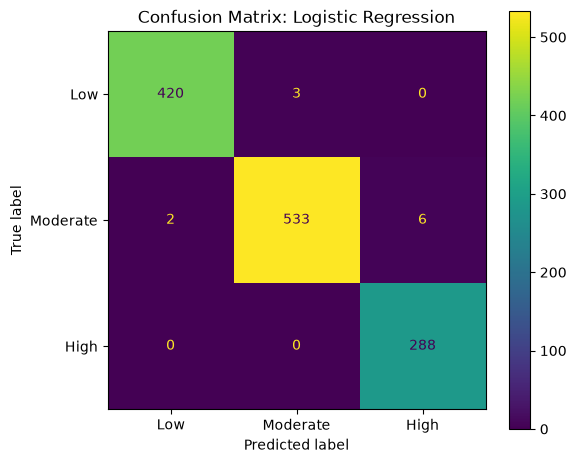

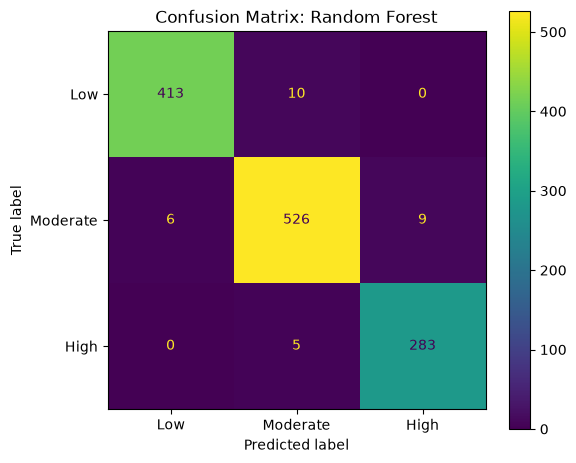

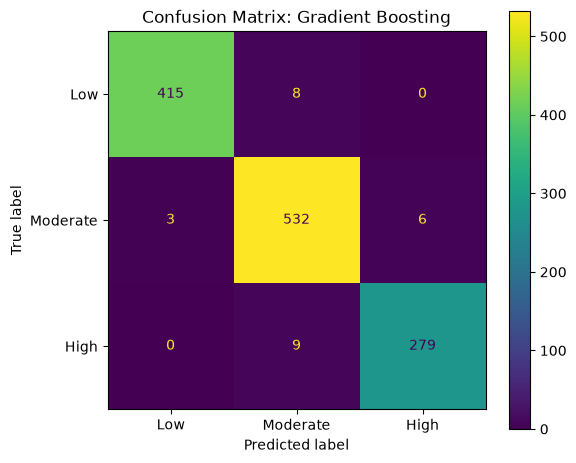

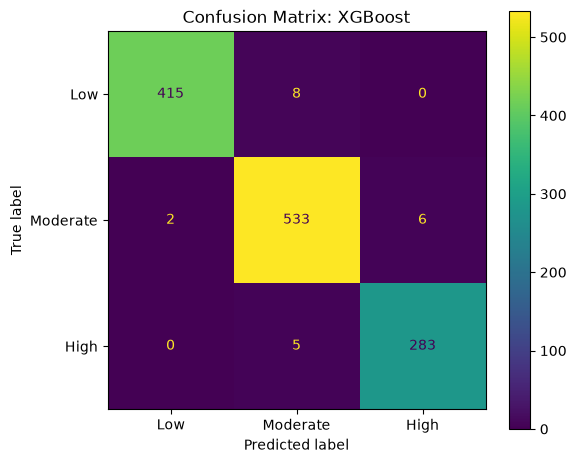

In [46]:
# ============================================================
# 15. DISPLAY CONFUSION MATRICES
# ============================================================
# A confusion matrix shows:
#
# - Correct class predictions along the diagonal
# - Incorrect class predictions outside the diagonal
#
# A separate figure is produced for every model using predictions
# from the held-out 30% test set.

for model_name, trained_model in trained_models.items():

    y_test_pred = trained_model.predict(
        X_test
    )

    confusion = confusion_matrix(
        y_test,
        y_test_pred,
        labels=CLASS_LABELS
    )

    display_object = ConfusionMatrixDisplay(
        confusion_matrix=confusion,
        display_labels=CLASS_NAMES
    )

    fig, ax = plt.subplots(
        figsize=(6, 5)
    )

    display_object.plot(
        ax=ax,
        values_format="d"
    )

    ax.set_title(
        f"Confusion Matrix: {model_name}"
    )

    plt.tight_layout()
    plt.show()

,Model,Macro F1
0,Logistic Regression,0.9912
1,XGBoost,0.9832
2,Gradient Boosting,0.9790
3,Random Forest,0.9764


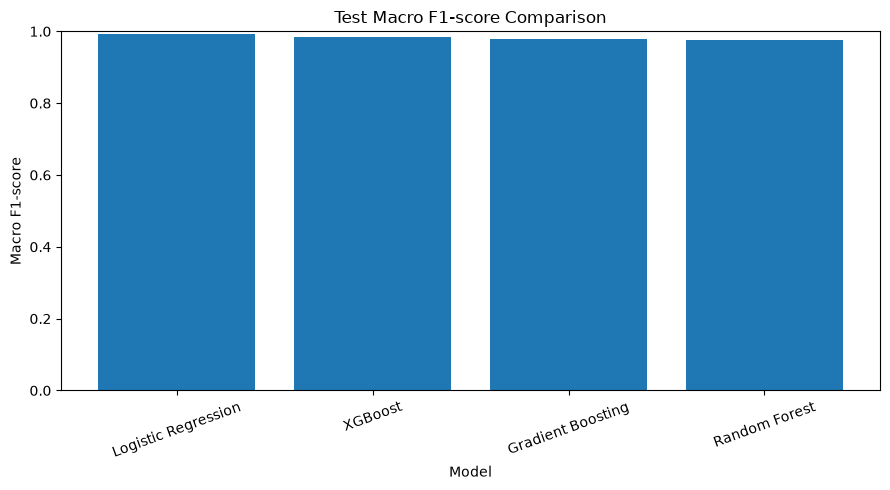

In [47]:
# ============================================================
# 16. COMPARE TEST MACRO F1-SCORES
# ============================================================
# Macro F1 gives equal importance to:
#
# - Low feasibility
# - Moderate feasibility
# - High feasibility
#
# Therefore, it is more suitable than accuracy when the target
# classes are not perfectly balanced.

macro_f1_comparison = (
    test_results_df[
        ["Model", "Macro F1"]
    ]
    .sort_values(
        by="Macro F1",
        ascending=False
    )
)

display(
    macro_f1_comparison.round(4)
)

plt.figure(
    figsize=(9, 5)
)

plt.bar(
    macro_f1_comparison["Model"],
    macro_f1_comparison["Macro F1"]
)

plt.title(
    "Test Macro F1-score Comparison"
)

plt.xlabel(
    "Model"
)

plt.ylabel(
    "Macro F1-score"
)

plt.ylim(
    0,
    1
)

plt.xticks(
    rotation=20
)

plt.tight_layout()
plt.show()

In [48]:
# ============================================================
# 17. DEFINE FIVE-FOLD STRATIFIED CROSS-VALIDATION
# ============================================================
# StratifiedKFold creates five different train-validation
# combinations.
#
# Each fold maintains approximately the same target class
# proportions.
#
# shuffle=True randomizes the observations before constructing
# the folds.

stratified_cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=RANDOM_STATE
)

stratified_cv

StratifiedKFold(n_splits=5, random_state=42, shuffle=True)

In [49]:
# ============================================================
# 18. DEFINE CROSS-VALIDATION METRICS
# ============================================================
# Custom scorers are used so that zero_division=0 prevents
# warnings when a model does not predict one of the classes.

macro_precision_scorer = make_scorer(
    precision_score,
    average="macro",
    zero_division=0
)

macro_recall_scorer = make_scorer(
    recall_score,
    average="macro",
    zero_division=0
)

macro_f1_scorer = make_scorer(
    f1_score,
    average="macro",
    zero_division=0
)

cross_validation_scoring = {
    "accuracy": "accuracy",
    "macro_precision": macro_precision_scorer,
    "macro_recall": macro_recall_scorer,
    "macro_f1": macro_f1_scorer
}

In [50]:
# ============================================================
# 19. PERFORM FIVE-FOLD CROSS-VALIDATION
# ============================================================
# Cross-validation is performed using the complete pipeline.
#
# Therefore, the preprocessor is fitted separately inside
# every training fold.
#
# This prevents validation-fold information from leaking into
# training.

cross_validation_results = []

for model_name, model_pipeline in models.items():

    print("=" * 60)
    print(
        f"Running five-fold cross-validation: {model_name}"
    )

    cv_result = cross_validate(
        estimator=model_pipeline,
        X=X_train,
        y=y_train,
        cv=stratified_cv,
        scoring=cross_validation_scoring,
        return_train_score=False,
        n_jobs=-1
    )

    result_row = {
        "Model": model_name,

        "CV Accuracy Mean": np.mean(
            cv_result["test_accuracy"]
        ),

        "CV Accuracy Std": np.std(
            cv_result["test_accuracy"]
        ),

        "CV Macro Precision Mean": np.mean(
            cv_result["test_macro_precision"]
        ),

        "CV Macro Recall Mean": np.mean(
            cv_result["test_macro_recall"]
        ),

        "CV Macro F1 Mean": np.mean(
            cv_result["test_macro_f1"]
        ),

        "CV Macro F1 Std": np.std(
            cv_result["test_macro_f1"]
        )
    }

    cross_validation_results.append(
        result_row
    )

    print(
        f"Mean Macro F1: "
        f"{result_row['CV Macro F1 Mean']:.4f}"
    )

Running five-fold cross-validation: Logistic Regression
Mean Macro F1: 0.9878
Running five-fold cross-validation: Random Forest
Mean Macro F1: 0.9730
Running five-fold cross-validation: Gradient Boosting
Mean Macro F1: 0.9754
Running five-fold cross-validation: XGBoost
Mean Macro F1: 0.9757


In [51]:
# ============================================================
# 20. DISPLAY CROSS-VALIDATION RESULTS
# ============================================================

cross_validation_results_df = pd.DataFrame(
    cross_validation_results
)

cross_validation_results_df = (
    cross_validation_results_df
    .sort_values(
        by="CV Macro F1 Mean",
        ascending=False
    )
    .reset_index(drop=True)
)

display(
    cross_validation_results_df.round(4)
)

,Model,CV Accuracy Mean,CV Accuracy Std,CV Macro Precision Mean,CV Macro Recall Mean,CV Macro F1 Mean,CV Macro F1 Std
0,Logistic Regression,0.9873,0.0049,0.9865,0.9893,0.9878,0.0048
1,XGBoost,0.9753,0.0041,0.9763,0.9754,0.9757,0.0039
2,Gradient Boosting,0.9750,0.0050,0.9769,0.9741,0.9754,0.0048
3,Random Forest,0.9723,0.0044,0.9724,0.9739,0.9730,0.0037


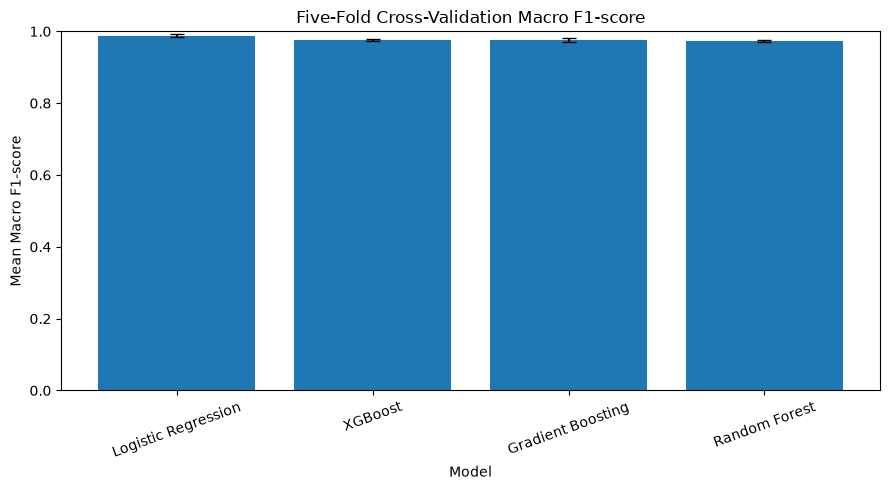

In [52]:
# ============================================================
# 21. PLOT CROSS-VALIDATION MACRO F1-SCORES
# ============================================================
# Error bars show the standard deviation across the five folds.
#
# A smaller standard deviation generally indicates more stable
# performance across different subsets of the data.

plt.figure(
    figsize=(9, 5)
)

plt.bar(
    cross_validation_results_df["Model"],
    cross_validation_results_df["CV Macro F1 Mean"],
    yerr=cross_validation_results_df["CV Macro F1 Std"],
    capsize=5
)

plt.title(
    "Five-Fold Cross-Validation Macro F1-score"
)

plt.xlabel(
    "Model"
)

plt.ylabel(
    "Mean Macro F1-score"
)

plt.ylim(
    0,
    1
)

plt.xticks(
    rotation=20
)

plt.tight_layout()
plt.show()

In [53]:
# ============================================================
# 22. PREPARE AREA-BASED VALIDATION
# ============================================================
# Area-based validation measures whether a model trained using
# some search areas can generalize to a completely different
# search area.
#
# GroupKFold ensures that observations from the same area do
# not appear in both the training and validation subsets.
#
# search_area is used as the grouping variable.

if "search_area" not in X_train.columns:
    raise ValueError(
        "search_area is required for area-based validation."
    )

area_groups = (
    X_train["search_area"]
    .astype("string")
    .fillna("Unknown")
)

number_of_areas = area_groups.nunique()

print(
    "Number of unique training areas:",
    number_of_areas
)

print("\nTraining observations by area:")

display(
    area_groups
    .value_counts()
    .to_frame("observation_count")
)

Number of unique training areas: 9

Training observations by area:


,observation_count
search_area,
Baneshwor,378
Patan durbar square,362
Boudha stupa,360
New Road,360
Bhaktapur durbar square,351
Kirtipur,300
Koteshwor,289
Durbar Marg,286
Pulchowk,234


In [54]:
# ============================================================
# 23. CREATE THE AREA-BASED GROUP KFOLD
# ============================================================
# A maximum of five folds is used.
#
# When fewer than five areas are available, the number of
# folds is reduced to the number of available areas.

area_cv_splits = min(
    5,
    number_of_areas
)

if area_cv_splits < 2:
    raise ValueError(
        "At least two different search areas are required "
        "for area-based validation."
    )

area_group_cv = GroupKFold(
    n_splits=area_cv_splits
)

print(
    "Number of area-based validation folds:",
    area_cv_splits
)

Number of area-based validation folds: 5


In [55]:
# ============================================================
# 24. PERFORM AREA-BASED VALIDATION
# ============================================================
# In each fold:
#
# - One or more complete areas are used for validation
# - The remaining areas are used for model training
#
# This is a harder test than normal random cross-validation
# because the validation area is geographically unseen.

area_validation_results = []

for model_name, model_pipeline in models.items():

    print("=" * 60)
    print(
        f"Running area-based validation: {model_name}"
    )

    area_result = cross_validate(
        estimator=model_pipeline,
        X=X_train,
        y=y_train,
        groups=area_groups,
        cv=area_group_cv,
        scoring=cross_validation_scoring,
        return_train_score=False,
        n_jobs=-1
    )

    result_row = {
        "Model": model_name,

        "Area Accuracy Mean": np.mean(
            area_result["test_accuracy"]
        ),

        "Area Accuracy Std": np.std(
            area_result["test_accuracy"]
        ),

        "Area Macro Precision Mean": np.mean(
            area_result["test_macro_precision"]
        ),

        "Area Macro Recall Mean": np.mean(
            area_result["test_macro_recall"]
        ),

        "Area Macro F1 Mean": np.mean(
            area_result["test_macro_f1"]
        ),

        "Area Macro F1 Std": np.std(
            area_result["test_macro_f1"]
        )
    }

    area_validation_results.append(
        result_row
    )

    print(
        f"Mean area Macro F1: "
        f"{result_row['Area Macro F1 Mean']:.4f}"
    )

Running area-based validation: Logistic Regression
Mean area Macro F1: 0.9811
Running area-based validation: Random Forest


Mean area Macro F1: 0.9380
Running area-based validation: Gradient Boosting
Mean area Macro F1: 0.9398
Running area-based validation: XGBoost
Mean area Macro F1: 0.9480


In [56]:
# ============================================================
# 25. DISPLAY AREA-BASED VALIDATION RESULTS
# ============================================================

area_validation_results_df = pd.DataFrame(
    area_validation_results
)

area_validation_results_df = (
    area_validation_results_df
    .sort_values(
        by="Area Macro F1 Mean",
        ascending=False
    )
    .reset_index(drop=True)
)

display(
    area_validation_results_df.round(4)
)

,Model,Area Accuracy Mean,Area Accuracy Std,Area Macro Precision Mean,Area Macro Recall Mean,Area Macro F1 Mean,Area Macro F1 Std
0,Logistic Regression,0.9833,0.0052,0.9817,0.9812,0.9811,0.0067
1,XGBoost,0.9576,0.0153,0.9553,0.9425,0.9480,0.0202
2,Gradient Boosting,0.9489,0.0161,0.9496,0.9317,0.9398,0.0195
3,Random Forest,0.9474,0.0208,0.9498,0.9295,0.9380,0.0223


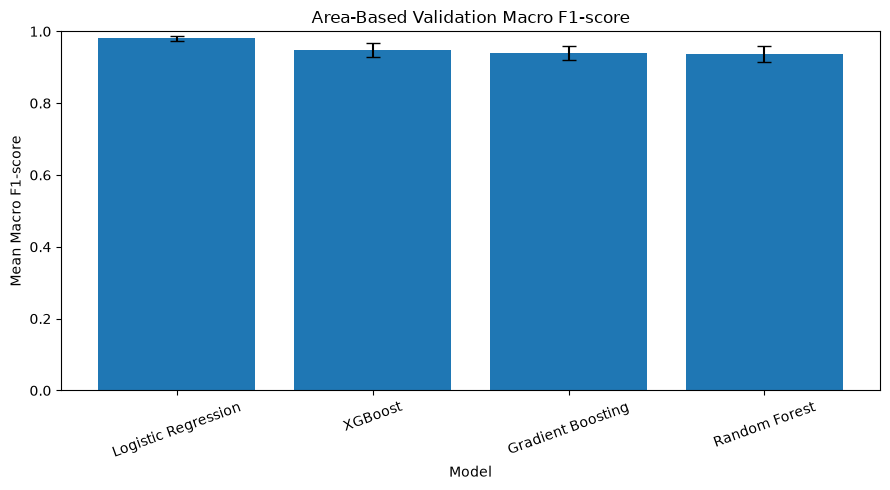

In [57]:
# ============================================================
# 26. PLOT AREA-BASED MACRO F1-SCORES
# ============================================================

plt.figure(
    figsize=(9, 5)
)

plt.bar(
    area_validation_results_df["Model"],
    area_validation_results_df["Area Macro F1 Mean"],
    yerr=area_validation_results_df["Area Macro F1 Std"],
    capsize=5
)

plt.title(
    "Area-Based Validation Macro F1-score"
)

plt.xlabel(
    "Model"
)

plt.ylabel(
    "Mean Macro F1-score"
)

plt.ylim(
    0,
    1
)

plt.xticks(
    rotation=20
)

plt.tight_layout()
plt.show()

In [58]:
# ============================================================
# 27. COMBINE MODEL EVALUATION RESULTS
# ============================================================
# This table compares:
#
# - Test-set Macro F1
# - Five-fold CV Macro F1
# - Area-based Macro F1
#
# The test set provides final unseen-row performance.
#
# Five-fold CV provides general model stability.
#
# Area-based validation provides geographic generalization
# performance.

combined_results_df = (
    test_results_df[
        [
            "Model",
            "Accuracy",
            "Macro F1",
            "Log Loss"
        ]
    ]
    .merge(
        cross_validation_results_df[
            [
                "Model",
                "CV Macro F1 Mean",
                "CV Macro F1 Std"
            ]
        ],
        on="Model",
        how="left"
    )
    .merge(
        area_validation_results_df[
            [
                "Model",
                "Area Macro F1 Mean",
                "Area Macro F1 Std"
            ]
        ],
        on="Model",
        how="left"
    )
)

combined_results_df = (
    combined_results_df
    .sort_values(
        by="CV Macro F1 Mean",
        ascending=False
    )
    .reset_index(drop=True)
)

display(
    combined_results_df.round(4)
)

,Model,Accuracy,Macro F1,Log Loss,CV Macro F1 Mean,CV Macro F1 Std,Area Macro F1 Mean,Area Macro F1 Std
0,Logistic Regression,0.9912,0.9912,0.0524,0.9878,0.0048,0.9811,0.0067
1,XGBoost,0.9832,0.9832,0.0535,0.9757,0.0039,0.9480,0.0202
2,Gradient Boosting,0.9792,0.9790,0.0732,0.9754,0.0048,0.9398,0.0195
3,Random Forest,0.9760,0.9764,0.1005,0.9730,0.0037,0.9380,0.0223


In [59]:
# ============================================================
# 28. SELECT THE BEST MODEL
# ============================================================
# The best model is selected using mean five-fold
# cross-validation Macro F1.
#
# The test-set score is not used as the primary model-selection
# criterion because repeatedly selecting models based on the
# test set could cause test-set overfitting.

best_model_name = (
    cross_validation_results_df
    .iloc[0]["Model"]
)

best_base_pipeline = models[
    best_model_name
]

best_cv_macro_f1 = (
    cross_validation_results_df
    .iloc[0]["CV Macro F1 Mean"]
)

print(
    "Best model before tuning:",
    best_model_name
)

print(
    "Mean five-fold CV Macro F1:",
    round(best_cv_macro_f1, 4)
)

Best model before tuning: Logistic Regression
Mean five-fold CV Macro F1: 0.9878


In [60]:
# ============================================================
# 29. DEFINE HYPERPARAMETER GRIDS
# ============================================================
# Each algorithm requires a different set of parameters.
#
# Parameters beginning with classifier__ refer to the
# classifier inside the Pipeline.
#
# GridSearchCV will test every parameter combination using
# five-fold stratified cross-validation.

parameter_grids = {
    "Logistic Regression": {
        "classifier__C": [
            0.01,
            0.1,
            1,
            10,
            100
        ],

        "classifier__solver": [
            "lbfgs",
            "newton-cg"
        ]
    },

    "Random Forest": {
        "classifier__n_estimators": [
            200,
            300,
            500
        ],

        "classifier__max_depth": [
            None,
            10,
            20
        ],

        "classifier__min_samples_split": [
            2,
            5,
            10
        ],

        "classifier__min_samples_leaf": [
            1,
            2,
            4
        ],

        "classifier__max_features": [
            "sqrt",
            "log2"
        ]
    },

    "Gradient Boosting": {
        "classifier__n_estimators": [
            100,
            200,
            300
        ],

        "classifier__learning_rate": [
            0.01,
            0.05,
            0.1
        ],

        "classifier__max_depth": [
            2,
            3,
            4
        ],

        "classifier__min_samples_split": [
            2,
            5
        ],

        "classifier__subsample": [
            0.8,
            1.0
        ]
    }
}

if XGBOOST_AVAILABLE:

    parameter_grids["XGBoost"] = {
        "classifier__n_estimators": [
            150,
            250,
            350
        ],

        "classifier__learning_rate": [
            0.01,
            0.05,
            0.1
        ],

        "classifier__max_depth": [
            3,
            4,
            6
        ],

        "classifier__subsample": [
            0.8,
            1.0
        ],

        "classifier__colsample_bytree": [
            0.8,
            1.0
        ]
    }

print(
    f"Hyperparameter grid prepared for: "
    f"{best_model_name}"
)

Hyperparameter grid prepared for: Logistic Regression


In [61]:
# ============================================================
# 30. TUNE THE BEST-PERFORMING MODEL
# ============================================================
# GridSearchCV:
#
# - Tries different hyperparameter combinations
# - Evaluates each combination using five-fold CV
# - Selects the combination with the highest Macro F1
#
# refit=True:
# After finding the best combination, the model is retrained
# using the complete training dataset.

best_model_parameter_grid = parameter_grids[
    best_model_name
]

grid_search = GridSearchCV(
    estimator=best_base_pipeline,
    param_grid=best_model_parameter_grid,
    scoring=macro_f1_scorer,
    cv=stratified_cv,
    n_jobs=-1,
    verbose=2,
    refit=True,
    return_train_score=True
)

grid_search.fit(
    X_train,
    y_train
)

print("Hyperparameter tuning completed.")

Fitting 5 folds for each of 10 candidates, totalling 50 fits
Hyperparameter tuning completed.


In [62]:
# ============================================================
# 31. DISPLAY THE BEST HYPERPARAMETERS
# ============================================================

print(
    "Tuned model:",
    best_model_name
)

print(
    "\nBest cross-validation Macro F1:",
    round(grid_search.best_score_, 4)
)

print("\nBest hyperparameters:")

for parameter_name, parameter_value in (
    grid_search.best_params_.items()
):
    print(
        f"{parameter_name}: {parameter_value}"
    )

Tuned model: Logistic Regression

Best cross-validation Macro F1: 0.9946

Best hyperparameters:
classifier__C: 100
classifier__solver: lbfgs


In [63]:
# ============================================================
# 32. STORE THE TUNED MODEL
# ============================================================
# best_estimator_ contains the complete fitted pipeline:
#
# - Missing-value imputation
# - Numerical normalization
# - One-hot encoding
# - Tuned classifier

tuned_best_model = (
    grid_search.best_estimator_
)

print(
    "The complete tuned model pipeline is ready."
)

The complete tuned model pipeline is ready.


In [64]:
# ============================================================
# 33. EVALUATE THE TUNED MODEL ON THE TEST SET
# ============================================================
# The untouched 30% test set is used to evaluate the final tuned
# model.
#
# This provides a more trustworthy estimate of its final
# predictive performance.

tuned_test_result = evaluate_model(
    model_name=f"Tuned {best_model_name}",
    model_pipeline=tuned_best_model,
    X_data=X_test,
    y_true=y_test
)

tuned_test_results_df = pd.DataFrame(
    [tuned_test_result]
)

display(
    tuned_test_results_df.round(4)
)

,Model,Accuracy,Macro Precision,Macro Recall,Macro F1,Weighted F1,Log Loss,Training Time
0,Tuned Logistic Regression,0.996,0.9955,0.9967,0.9961,0.996,0.0116,NaN


In [65]:
# ============================================================
# 34. DISPLAY THE TUNED MODEL CLASSIFICATION REPORT
# ============================================================

tuned_y_pred = tuned_best_model.predict(
    X_test
)

print(
    classification_report(
        y_test,
        tuned_y_pred,
        labels=CLASS_LABELS,
        target_names=CLASS_NAMES,
        zero_division=0
    )
)

              precision    recall  f1-score   support

         Low       1.00      1.00      1.00       423
    Moderate       1.00      0.99      1.00       541
        High       0.99      1.00      1.00       288

    accuracy                           1.00      1252
   macro avg       1.00      1.00      1.00      1252
weighted avg       1.00      1.00      1.00      1252



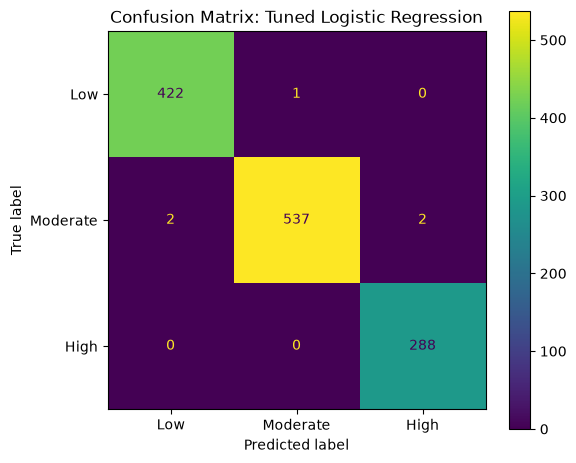

In [66]:
# ============================================================
# 35. DISPLAY THE TUNED MODEL CONFUSION MATRIX
# ============================================================
# This confusion matrix uses the held-out 30% test set.

tuned_confusion_matrix = confusion_matrix(
    y_test,
    tuned_y_pred,
    labels=CLASS_LABELS
)

tuned_confusion_display = ConfusionMatrixDisplay(
    confusion_matrix=tuned_confusion_matrix,
    display_labels=CLASS_NAMES
)

fig, ax = plt.subplots(
    figsize=(6, 5)
)

tuned_confusion_display.plot(
    ax=ax,
    values_format="d"
)

ax.set_title(
    f"Confusion Matrix: Tuned {best_model_name}"
)

plt.tight_layout()
plt.show()

In [67]:
# ============================================================
# 36. COMPARE THE BASE AND TUNED MODEL
# ============================================================
# This comparison determines whether hyperparameter tuning
# improved the model's test performance.

base_model_result = (
    test_results_df[
        test_results_df["Model"] == best_model_name
    ]
    .copy()
)

base_model_result["Version"] = "Before tuning"

tuned_model_result = (
    tuned_test_results_df.copy()
)

tuned_model_result["Version"] = "After tuning"

base_tuned_comparison = pd.concat(
    [
        base_model_result[
            [
                "Version",
                "Accuracy",
                "Macro Precision",
                "Macro Recall",
                "Macro F1",
                "Weighted F1",
                "Log Loss"
            ]
        ],

        tuned_model_result[
            [
                "Version",
                "Accuracy",
                "Macro Precision",
                "Macro Recall",
                "Macro F1",
                "Weighted F1",
                "Log Loss"
            ]
        ]
    ],
    ignore_index=True
)

display(
    base_tuned_comparison.round(4)
)

,Version,Accuracy,Macro Precision,Macro Recall,Macro F1,Weighted F1,Log Loss
0,Before tuning,0.9912,0.9898,0.9927,0.9912,0.9912,0.0524
1,After tuning,0.9960,0.9955,0.9967,0.9961,0.9960,0.0116


In [68]:
# ============================================================
# 37. EXAMINE GRID SEARCH RESULTS
# ============================================================
# This table displays the best hyperparameter combinations
# evaluated during tuning.

grid_search_results_df = pd.DataFrame(
    grid_search.cv_results_
)

grid_search_summary = (
    grid_search_results_df[
        [
            "rank_test_score",
            "mean_test_score",
            "std_test_score",
            "mean_train_score",
            "params"
        ]
    ]
    .sort_values(
        by="rank_test_score"
    )
    .head(10)
)

display(
    grid_search_summary
)

,rank_test_score,mean_test_score,std_test_score,mean_train_score,params
8,1,0.994631,0.001789,0.998958,"{'classifier__C': 100, 'classifier__solver': '..."
9,2,0.994327,0.002051,0.998712,"{'classifier__C': 100, 'classifier__solver': '..."
7,3,0.994030,0.001785,0.997386,"{'classifier__C': 10, 'classifier__solver': 'n..."
6,4,0.993728,0.002424,0.997386,"{'classifier__C': 10, 'classifier__solver': 'l..."
4,5,0.987838,0.004844,0.990042,"{'classifier__C': 1, 'classifier__solver': 'lb..."
5,6,0.987460,0.005069,0.990042,"{'classifier__C': 1, 'classifier__solver': 'ne..."
2,7,0.971826,0.003075,0.974755,"{'classifier__C': 0.1, 'classifier__solver': '..."
3,7,0.971826,0.003075,0.974661,"{'classifier__C': 0.1, 'classifier__solver': '..."
1,9,0.945877,0.006597,0.948273,"{'classifier__C': 0.01, 'classifier__solver': ..."
0,9,0.945877,0.006597,0.948273,"{'classifier__C': 0.01, 'classifier__solver': ..."


In [69]:
# ============================================================
# 38. FINAL PHASE 4 SUMMARY
# ============================================================

print("=" * 60)
print("PHASE 4 COMPLETED SUCCESSFULLY")
print("=" * 60)

print(
    "\nModels evaluated:",
    list(models.keys())
)

print(
    "\nBest model before tuning:",
    best_model_name
)

print(
    "Best untuned CV Macro F1:",
    round(best_cv_macro_f1, 4)
)

print(
    "Best tuned CV Macro F1:",
    round(grid_search.best_score_, 4)
)

print(
    "Tuned test Macro F1:",
    round(
        tuned_test_result["Macro F1"],
        4
    )
)

print(
    "\nThe final tuned pipeline is stored in:"
)

print(
    "tuned_best_model"
)

PHASE 4 COMPLETED SUCCESSFULLY

Models evaluated: ['Logistic Regression', 'Random Forest', 'Gradient Boosting', 'XGBoost']

Best model before tuning: Logistic Regression
Best untuned CV Macro F1: 0.9878
Best tuned CV Macro F1: 0.9946
Tuned test Macro F1: 0.9961

The final tuned pipeline is stored in:
tuned_best_model


In [70]:
print("Selected final model:", best_model_name)
print("Best parameters:", grid_search.best_params_)
print("CV Macro F1:", grid_search.best_score_)
print("Test Macro F1:", tuned_test_result["Macro F1"])
print("Test accuracy:", tuned_test_result["Accuracy"])

Selected final model: Logistic Regression
Best parameters: {'classifier__C': 100, 'classifier__solver': 'lbfgs'}
CV Macro F1: 0.9946308843889311
Test Macro F1: 0.9961213198193836
Test accuracy: 0.9960063897763578


In [71]:
# ============================================================
# 39. CREATE DIRECTORY FOR THE FINAL MODEL
# ============================================================
# The trained model will be saved inside the backend/models
# directory.
#
# parents=True:
# Creates parent folders when they do not already exist.
#
# exist_ok=True:
# Prevents an error when the folder already exists.

from pathlib import Path

MODEL_DIRECTORY = Path(
    "../backend/models"
)

MODEL_DIRECTORY.mkdir(
    parents=True,
    exist_ok=True
)

MODEL_PATH = (
    MODEL_DIRECTORY
    / "restaurant_feasibility_pipeline_70_30.joblib"
)

print(
    "Model will be saved at:"
)

print(
    MODEL_PATH.resolve()
)

Model will be saved at:
C:\Users\dipsh\OneDrive\Desktop\Minor_New\backend\models\restaurant_feasibility_pipeline_70_30.joblib


In [72]:
# ============================================================
# 40. PREPARE MODEL METADATA
# ============================================================
# Metadata stores additional information required during
# prediction and deployment.
#
# It includes:
#
# - Selected model name
# - Required input features
# - Numerical features
# - Categorical features
# - Class-label mapping
# - Train-test split configuration
# - Final evaluation results

model_metadata = {
    "model_name": best_model_name,

    "train_test_split": "70:30",

    "train_percentage": 70,

    "test_percentage": 30,

    "random_state": RANDOM_STATE,

    "training_rows": int(len(X_train)),

    "testing_rows": int(len(X_test)),

    "model_features": MODEL_FEATURES,

    "numeric_features": NUMERIC_FEATURES,

    "categorical_features": CATEGORICAL_FEATURES,

    "label_mapping": {
        0: "Low",
        1: "Moderate",
        2: "High"
    },

    "best_hyperparameters": grid_search.best_params_,

    "cross_validation_macro_f1": float(
        grid_search.best_score_
    ),

    "test_accuracy": float(
        tuned_test_result["Accuracy"]
    ),

    "test_macro_f1": float(
        tuned_test_result["Macro F1"]
    ),

    "test_macro_precision": float(
        tuned_test_result["Macro Precision"]
    ),

    "test_macro_recall": float(
        tuned_test_result["Macro Recall"]
    )
}

print("Model metadata prepared.")

model_metadata

Model metadata prepared.


{'model_name': 'Logistic Regression',
 'train_test_split': '70:30',
 'train_percentage': 70,
 'test_percentage': 30,
 'random_state': 42,
 'training_rows': 2920,
 'testing_rows': 1252,
 'model_features': ['commercial_score',
  'accessibility_score',
  'education_score',
  'health_activity_score',
  'attraction_score',
  'cultural_activity_score',
  'market_gap_score',
  'competition_pressure_score',
  'search_area'],
 'numeric_features': ['commercial_score',
  'accessibility_score',
  'education_score',
  'health_activity_score',
  'attraction_score',
  'cultural_activity_score',
  'market_gap_score',
  'competition_pressure_score'],
 'categorical_features': ['search_area'],
 'label_mapping': {0: 'Low', 1: 'Moderate', 2: 'High'},
 'best_hyperparameters': {'classifier__C': 100, 'classifier__solver': 'lbfgs'},
 'cross_validation_macro_f1': 0.9946308843889311,
 'test_accuracy': 0.9960063897763578,
 'test_macro_f1': 0.9961213198193836,
 'test_macro_precision': 0.995509243694769,
 'test_mac

In [73]:
# ============================================================
# 41. SAVE THE COMPLETE FINAL MODEL PACKAGE
# ============================================================
# The model package contains:
#
# pipeline:
# - Missing-value imputation
# - Numerical normalization
# - One-hot encoding
# - Tuned classifier
#
# metadata:
# - Required feature names
# - Class mappings
# - Evaluation scores
# - Hyperparameters
#
# Saving the complete pipeline is important because Phase 5
# must perform exactly the same preprocessing used during
# model training.

import joblib

model_package = {
    "pipeline": tuned_best_model,
    "metadata": model_metadata
}

joblib.dump(
    model_package,
    MODEL_PATH
)

print(
    "Final model package saved successfully."
)

print(
    "Saved model path:"
)

print(
    MODEL_PATH.resolve()
)

Final model package saved successfully.
Saved model path:
C:\Users\dipsh\OneDrive\Desktop\Minor_New\backend\models\restaurant_feasibility_pipeline_70_30.joblib


In [74]:
# ============================================================
# 42. VERIFY THE SAVED MODEL FILE
# ============================================================

if MODEL_PATH.exists():

    file_size_mb = (
        MODEL_PATH.stat().st_size
        / (1024 * 1024)
    )

    print(
        "Model file exists."
    )

    print(
        f"Model file size: {file_size_mb:.2f} MB"
    )

else:

    raise FileNotFoundError(
        "The model file was not saved successfully."
    )

Model file exists.
Model file size: 0.01 MB


In [75]:
# ============================================================
# 43. RELOAD THE SAVED MODEL PACKAGE
# ============================================================
# Reloading the model verifies that it can be used in a
# different notebook or by the FastAPI backend.

loaded_model_package = joblib.load(
    MODEL_PATH
)

loaded_pipeline = loaded_model_package[
    "pipeline"
]

loaded_metadata = loaded_model_package[
    "metadata"
]

print(
    "Saved model package loaded successfully."
)

print(
    "Saved model name:",
    loaded_metadata["model_name"]
)

print(
    "Saved test accuracy:",
    round(
        loaded_metadata["test_accuracy"],
        4
    )
)

print(
    "Saved test Macro F1:",
    round(
        loaded_metadata["test_macro_f1"],
        4
    )
)

Saved model package loaded successfully.
Saved model name: Logistic Regression
Saved test accuracy: 0.996
Saved test Macro F1: 0.9961


In [76]:
# ============================================================
# 44. VERIFY THE RELOADED MODEL PREDICTIONS
# ============================================================
# Predictions from the saved and reloaded model should be
# identical to predictions from tuned_best_model.

original_predictions = tuned_best_model.predict(
    X_test
)

reloaded_predictions = loaded_pipeline.predict(
    X_test
)

predictions_are_equal = np.array_equal(
    original_predictions,
    reloaded_predictions
)

print(
    "Original and reloaded predictions are identical:",
    predictions_are_equal
)

if not predictions_are_equal:
    raise ValueError(
        "Reloaded model predictions do not match the original."
    )

Original and reloaded predictions are identical: True


In [77]:
# ============================================================
# . IMPORT LEARNING-CURVE TOOLS
# ============================================================
# The models used in Phase 4 are classical machine-learning
# models rather than neural networks.
#
# Therefore, they do not provide epoch-by-epoch histories.
#
# Learning curves use only X_train and y_train, which represent
# the 70% training portion. Five-fold cross-validation then
# creates internal training and validation folds.
#
# Learning curves evaluate each model using increasing amounts
# of this training data and calculate:
#
# 1. Training accuracy
# 2. Validation accuracy
# 3. Training log loss
# 4. Validation log loss

from sklearn.model_selection import learning_curve

In [78]:
# ============================================================
#  DEFINE LEARNING-CURVE TRAINING SIZES
# ============================================================
# Eight progressively larger subsets of the training data
# will be used.
#
# The smallest subset uses 20% of the available 70% training pool,
# while the largest subset uses 100% of that training pool.
# This 0.20 is a learning-curve subset fraction; it is not the
# train-test split and therefore must remain unchanged.

learning_curve_train_sizes = np.linspace(
    0.20,
    1.00,
    8
)

print("Training-size fractions:")
print(learning_curve_train_sizes)

Training-size fractions:
[0.2        0.31428571 0.42857143 0.54285714 0.65714286 0.77142857
 0.88571429 1.        ]


In [79]:
# ============================================================
#  CALCULATE LEARNING CURVES FOR ALL PHASE 4 MODELS
# ============================================================
# X_train and y_train contain the 70% training portion.
# The held-out 30% test set is not used in these learning curves.
#
# The existing `models` dictionary contains the complete
# pipelines for:
#
# - Logistic Regression
# - Random Forest
# - Gradient Boosting
# - XGBoost, when available
#
# Accuracy:
# Higher values are better.
#
# Negative log loss:
# Scikit-learn returns negative log loss because model-selection
# scores are normally maximized. It is converted back to
# positive log loss below so that lower values indicate better
# performance.

learning_curve_results = {}

for model_name, model_pipeline in models.items():

    print("=" * 70)
    print(f"Calculating learning curves: {model_name}")

    # --------------------------------------------------------
    # Accuracy learning curve
    # --------------------------------------------------------

    (
        accuracy_train_sizes,
        training_accuracy_scores,
        validation_accuracy_scores
    ) = learning_curve(
        estimator=model_pipeline,
        X=X_train,
        y=y_train,
        train_sizes=learning_curve_train_sizes,
        cv=stratified_cv,
        scoring="accuracy",
        shuffle=True,
        random_state=RANDOM_STATE,
        n_jobs=-1
    )

    # Calculate the mean accuracy across the five folds
    mean_training_accuracy = np.mean(
        training_accuracy_scores,
        axis=1
    )

    mean_validation_accuracy = np.mean(
        validation_accuracy_scores,
        axis=1
    )

    # Calculate standard deviation across the five folds
    std_training_accuracy = np.std(
        training_accuracy_scores,
        axis=1
    )

    std_validation_accuracy = np.std(
        validation_accuracy_scores,
        axis=1
    )

    # --------------------------------------------------------
    # Log-loss learning curve
    # --------------------------------------------------------

    (
        loss_train_sizes,
        negative_training_loss_scores,
        negative_validation_loss_scores
    ) = learning_curve(
        estimator=model_pipeline,
        X=X_train,
        y=y_train,
        train_sizes=learning_curve_train_sizes,
        cv=stratified_cv,
        scoring="neg_log_loss",
        shuffle=True,
        random_state=RANDOM_STATE,
        n_jobs=-1
    )

    # Convert negative log loss back to positive log loss
    training_loss_scores = (
        -negative_training_loss_scores
    )

    validation_loss_scores = (
        -negative_validation_loss_scores
    )

    # Calculate mean log loss across the five folds
    mean_training_loss = np.mean(
        training_loss_scores,
        axis=1
    )

    mean_validation_loss = np.mean(
        validation_loss_scores,
        axis=1
    )

    # Calculate standard deviation across the five folds
    std_training_loss = np.std(
        training_loss_scores,
        axis=1
    )

    std_validation_loss = np.std(
        validation_loss_scores,
        axis=1
    )

    # Store results so they can be plotted later
    learning_curve_results[model_name] = {
        "train_sizes": accuracy_train_sizes,

        "mean_training_accuracy": mean_training_accuracy,
        "mean_validation_accuracy": mean_validation_accuracy,

        "std_training_accuracy": std_training_accuracy,
        "std_validation_accuracy": std_validation_accuracy,

        "mean_training_loss": mean_training_loss,
        "mean_validation_loss": mean_validation_loss,

        "std_training_loss": std_training_loss,
        "std_validation_loss": std_validation_loss
    }

    print(
        f"Learning curves completed for {model_name}."
    )

print("\nAll model learning curves calculated successfully.")

Calculating learning curves: Logistic Regression


Learning curves completed for Logistic Regression.
Calculating learning curves: Random Forest
Learning curves completed for Random Forest.
Calculating learning curves: Gradient Boosting
Learning curves completed for Gradient Boosting.
Calculating learning curves: XGBoost
Learning curves completed for XGBoost.

All model learning curves calculated successfully.


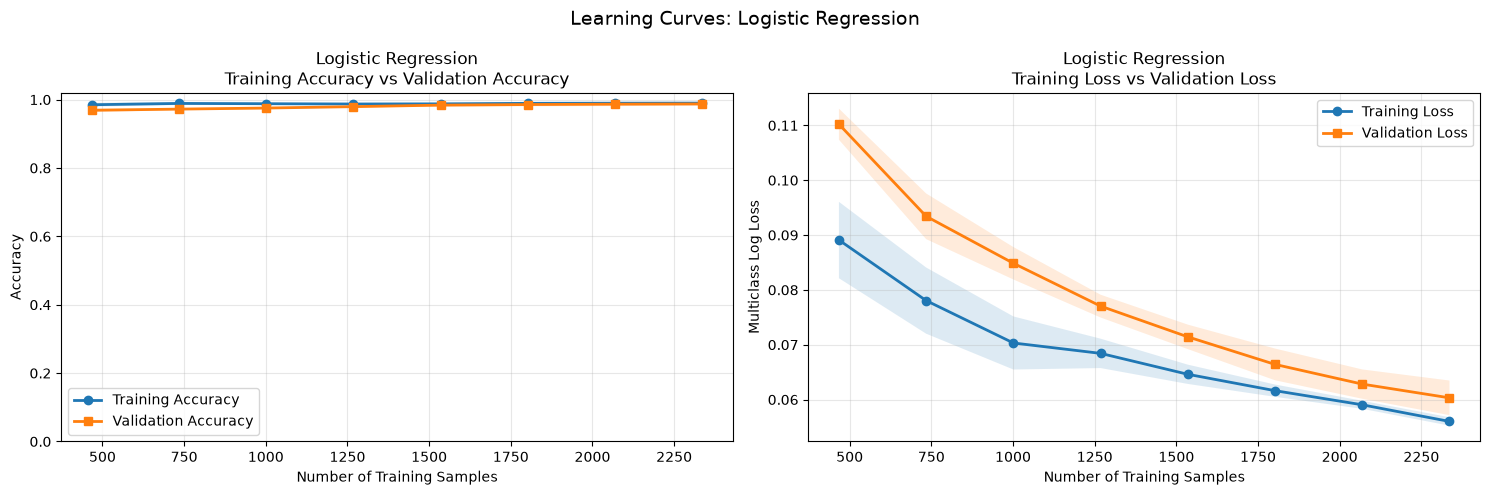

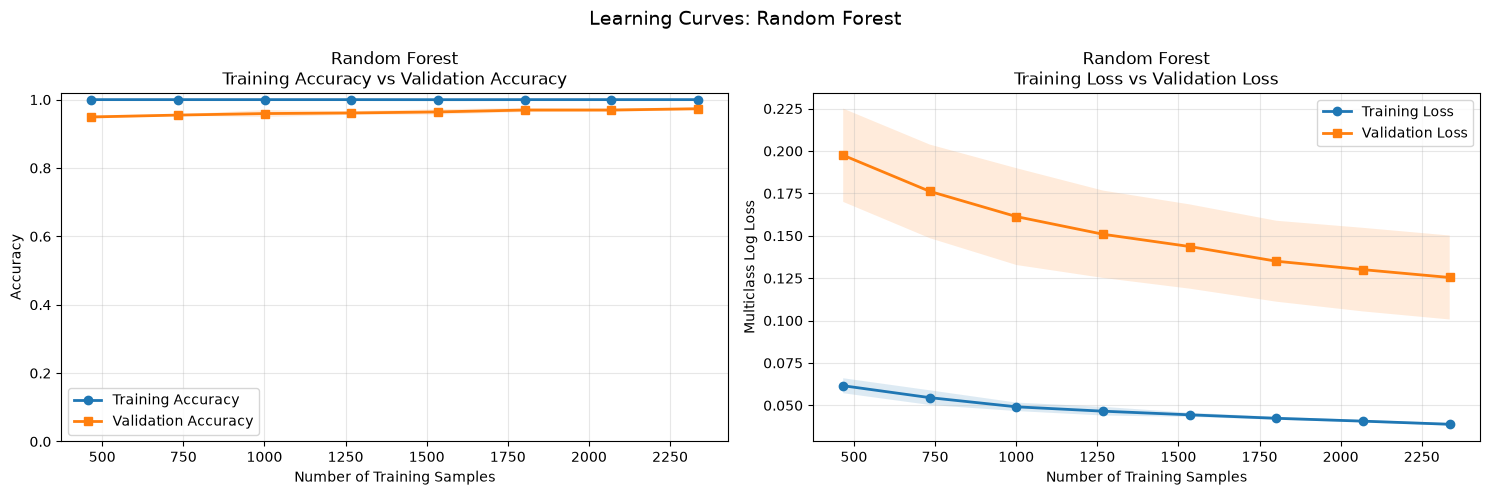

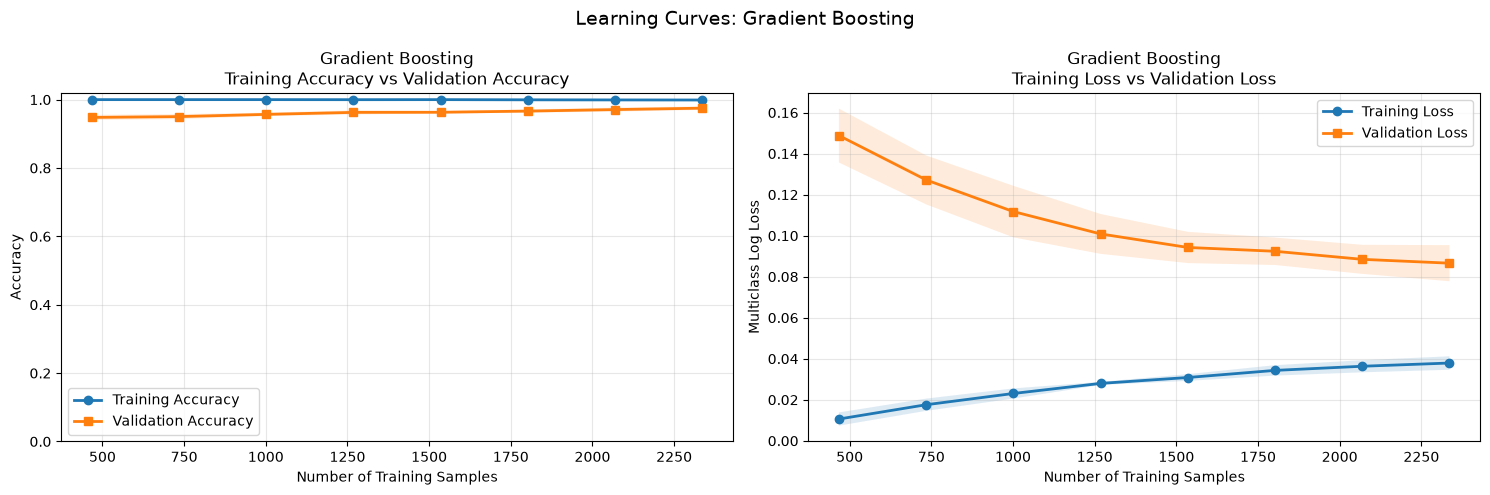

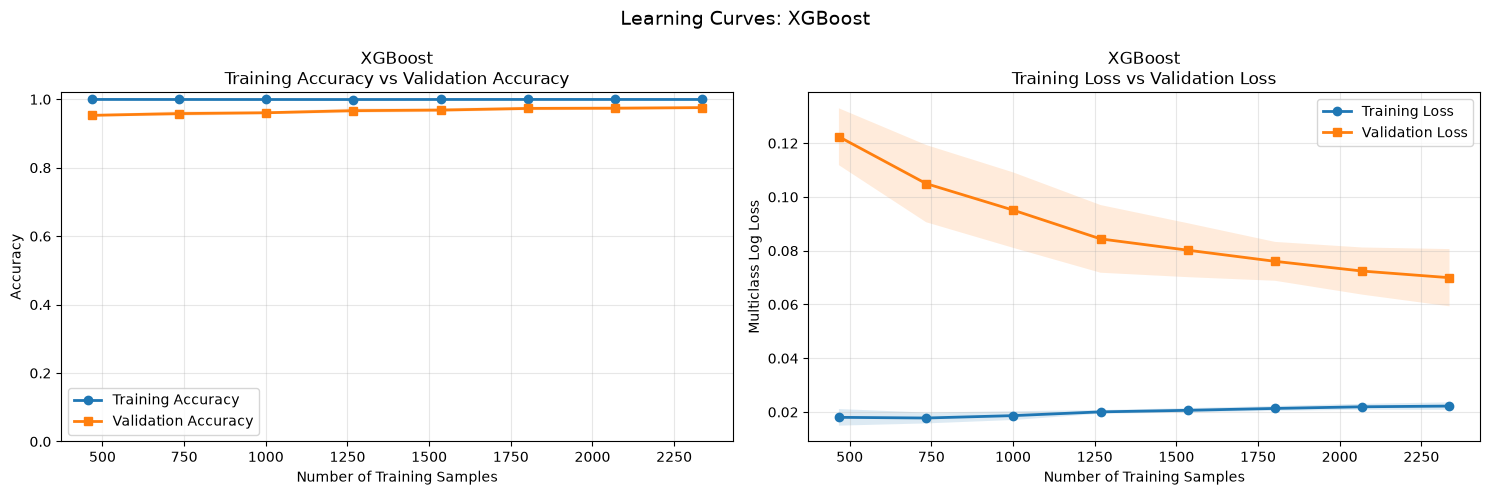

In [80]:
# ============================================================
#  PLOT ACCURACY AND LOSS CURVES FOR ALL MODELS
# ============================================================
# For every Phase 4 model, two graphs are displayed:
#
# Left:
# Training accuracy versus validation accuracy
#
# Right:
# Training loss versus validation loss
#
# The shaded regions represent one standard deviation across
# the five cross-validation folds.

for model_name, result in learning_curve_results.items():

    train_sizes = result["train_sizes"]

    fig, axes = plt.subplots(
        nrows=1,
        ncols=2,
        figsize=(15, 5)
    )

    # ========================================================
    # GRAPH 1: TRAINING VS VALIDATION ACCURACY
    # ========================================================

    axes[0].plot(
        train_sizes,
        result["mean_training_accuracy"],
        marker="o",
        linewidth=2,
        label="Training Accuracy"
    )

    axes[0].plot(
        train_sizes,
        result["mean_validation_accuracy"],
        marker="s",
        linewidth=2,
        label="Validation Accuracy"
    )

    # Show standard-deviation ranges
    axes[0].fill_between(
        train_sizes,
        result["mean_training_accuracy"]
        - result["std_training_accuracy"],
        result["mean_training_accuracy"]
        + result["std_training_accuracy"],
        alpha=0.15
    )

    axes[0].fill_between(
        train_sizes,
        result["mean_validation_accuracy"]
        - result["std_validation_accuracy"],
        result["mean_validation_accuracy"]
        + result["std_validation_accuracy"],
        alpha=0.15
    )

    axes[0].set_title(
        f"{model_name}\n"
        "Training Accuracy vs Validation Accuracy"
    )

    axes[0].set_xlabel(
        "Number of Training Samples"
    )

    axes[0].set_ylabel(
        "Accuracy"
    )

    axes[0].set_ylim(
        0,
        1.02
    )

    axes[0].grid(
        True,
        alpha=0.3
    )

    axes[0].legend()

    # ========================================================
    # GRAPH 2: TRAINING VS VALIDATION LOSS
    # ========================================================

    axes[1].plot(
        train_sizes,
        result["mean_training_loss"],
        marker="o",
        linewidth=2,
        label="Training Loss"
    )

    axes[1].plot(
        train_sizes,
        result["mean_validation_loss"],
        marker="s",
        linewidth=2,
        label="Validation Loss"
    )

    # Show standard-deviation ranges
    axes[1].fill_between(
        train_sizes,
        result["mean_training_loss"]
        - result["std_training_loss"],
        result["mean_training_loss"]
        + result["std_training_loss"],
        alpha=0.15
    )

    axes[1].fill_between(
        train_sizes,
        result["mean_validation_loss"]
        - result["std_validation_loss"],
        result["mean_validation_loss"]
        + result["std_validation_loss"],
        alpha=0.15
    )

    axes[1].set_title(
        f"{model_name}\n"
        "Training Loss vs Validation Loss"
    )

    axes[1].set_xlabel(
        "Number of Training Samples"
    )

    axes[1].set_ylabel(
        "Multiclass Log Loss"
    )

    axes[1].grid(
        True,
        alpha=0.3
    )

    axes[1].legend()

    fig.suptitle(
        f"Learning Curves: {model_name}",
        fontsize=14
    )

    plt.tight_layout()
    plt.show()

In [81]:
# ============================================================
# DISPLAY FINAL LEARNING-CURVE VALUES
# ============================================================
# This table shows the training and validation results obtained
# using the largest training subset for every model.
#
# A small training-validation gap generally suggests good
# generalization.
#
# A very high training score but noticeably lower validation
# score may suggest overfitting.

learning_curve_summary = []

for model_name, result in learning_curve_results.items():

    learning_curve_summary.append({
        "Model": model_name,

        "Training Samples": int(
            result["train_sizes"][-1]
        ),

        "Final Training Accuracy": (
            result["mean_training_accuracy"][-1]
        ),

        "Final Validation Accuracy": (
            result["mean_validation_accuracy"][-1]
        ),

        "Accuracy Gap": (
            result["mean_training_accuracy"][-1]
            - result["mean_validation_accuracy"][-1]
        ),

        "Final Training Loss": (
            result["mean_training_loss"][-1]
        ),

        "Final Validation Loss": (
            result["mean_validation_loss"][-1]
        ),

        "Loss Gap": (
            result["mean_validation_loss"][-1]
            - result["mean_training_loss"][-1]
        )
    })

learning_curve_summary_df = pd.DataFrame(
    learning_curve_summary
)

learning_curve_summary_df = (
    learning_curve_summary_df
    .sort_values(
        by="Final Validation Accuracy",
        ascending=False
    )
    .reset_index(drop=True)
)

display(
    learning_curve_summary_df.round(4)
)

,Model,Training Samples,Final Training Accuracy,Final Validation Accuracy,Accuracy Gap,Final Training Loss,Final Validation Loss,Loss Gap
0,Logistic Regression,2336,0.9898,0.9873,0.0025,0.0560,0.0603,0.0043
1,XGBoost,2336,0.9995,0.9757,0.0238,0.0222,0.0700,0.0477
2,Gradient Boosting,2336,0.9989,0.9750,0.0239,0.0379,0.0866,0.0487
3,Random Forest,2336,1.0000,0.9733,0.0267,0.0389,0.1254,0.0865


In [82]:
# ============================================================
#  IMPORT LIBRARIES FOR MULTICLASS ROC CURVES
# ============================================================
# ROC curves require:
#
# roc_curve:
# Calculates the false-positive rate and true-positive rate.
#
# auc:
# Calculates the area under each ROC curve.
#
# label_binarize:
# Converts the multiclass target into one-vs-rest binary
# columns:
#
# Low      -> [1, 0, 0]
# Moderate -> [0, 1, 0]
# High     -> [0, 0, 1]

from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize

print("ROC curve libraries imported successfully.")

ROC curve libraries imported successfully.


In [83]:
# ============================================================
#  BINARIZE THE TEST TARGET FOR MULTICLASS ROC
# ============================================================
# The ROC analysis below uses the held-out 30% test target.
# ROC analysis is originally designed for binary classification.
#
# Since this project has three classes, One-vs-Rest ROC is used:
#
# - Low versus all other classes
# - Moderate versus all other classes
# - High versus all other classes

y_test_binarized = label_binarize(
    y_test,
    classes=CLASS_LABELS
)

print(
    "Original test target shape:",
    y_test.shape
)

print(
    "Binarized test target shape:",
    y_test_binarized.shape
)

print("\nFirst five binarized target rows:")
print(y_test_binarized[:5])

Original test target shape: (1252,)
Binarized test target shape: (1252, 3)

First five binarized target rows:
[[1 0 0]
 [0 0 1]
 [0 0 1]
 [0 1 0]
 [0 0 1]]


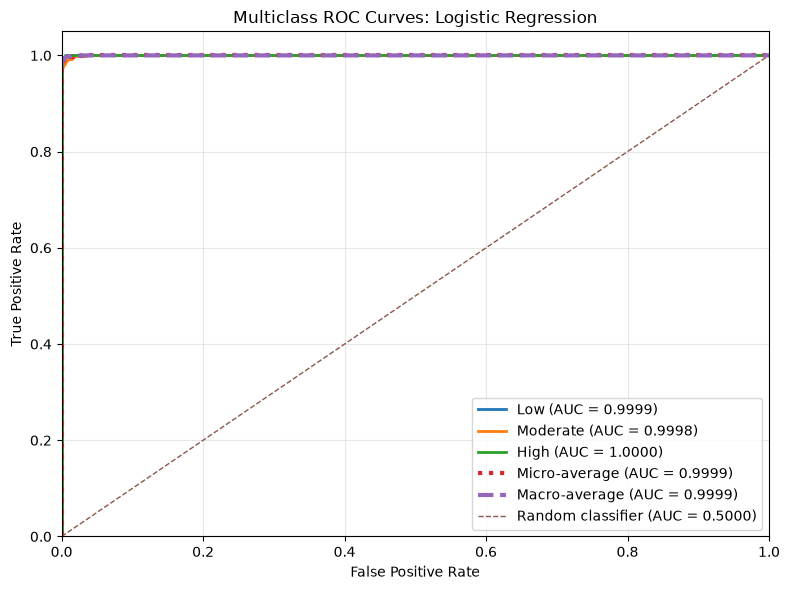

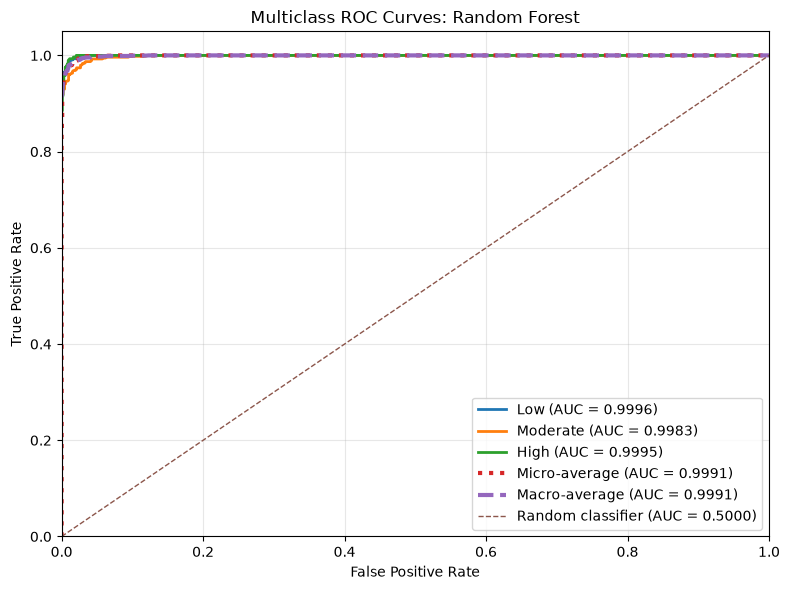

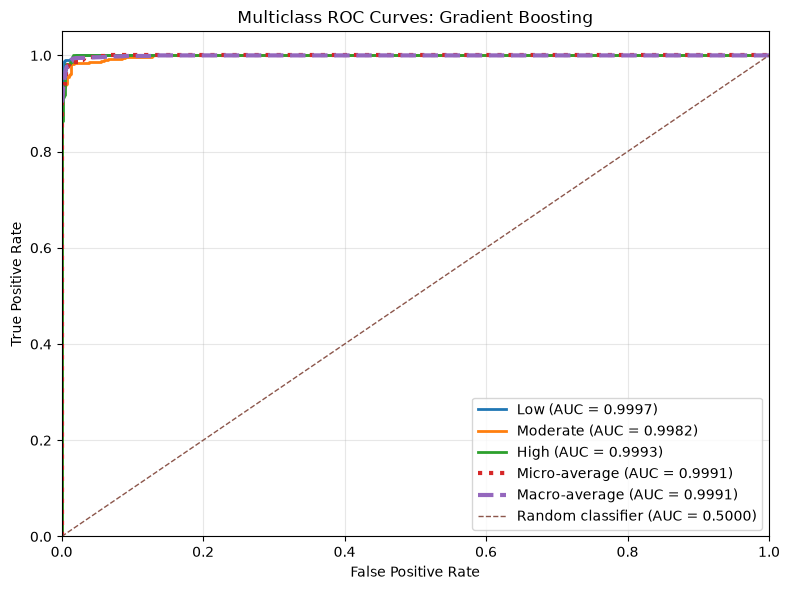

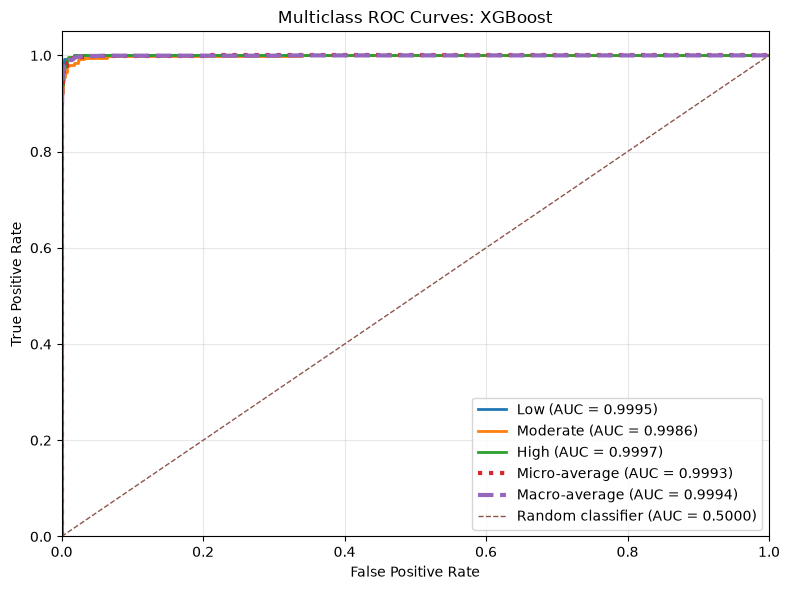

In [84]:
# ============================================================
# . DISPLAY MULTICLASS ROC CURVES FOR ALL MODELS
# ============================================================
# A separate ROC figure is generated for every trained model
# using predicted probabilities from the held-out 30% test set.
#
# Each figure contains:
#
# - Low class ROC curve
# - Moderate class ROC curve
# - High class ROC curve
# - Micro-average ROC curve
# - Macro-average ROC curve
#
# AUC interpretation:
#
# 1.00 = perfect discrimination
# 0.90 to 1.00 = excellent
# 0.80 to 0.90 = good
# 0.70 to 0.80 = acceptable
# 0.50 = no better than random guessing

roc_auc_results = []

number_of_classes = len(
    CLASS_LABELS
)

for model_name, trained_model in trained_models.items():

    # --------------------------------------------------------
    # Predict probabilities for the three classes
    # --------------------------------------------------------

    y_test_probability = trained_model.predict_proba(
        X_test
    )

    # Dictionaries store ROC values for every class
    false_positive_rate = {}
    true_positive_rate = {}
    roc_auc = {}

    # --------------------------------------------------------
    # Calculate one-vs-rest ROC curve for each class
    # --------------------------------------------------------

    for class_index in range(number_of_classes):

        false_positive_rate[class_index], \
        true_positive_rate[class_index], _ = roc_curve(
            y_test_binarized[:, class_index],
            y_test_probability[:, class_index]
        )

        roc_auc[class_index] = auc(
            false_positive_rate[class_index],
            true_positive_rate[class_index]
        )

    # --------------------------------------------------------
    # Calculate the micro-average ROC curve
    # --------------------------------------------------------
    # Micro-average combines every class prediction into one
    # collection before calculating the ROC curve.

    false_positive_rate["micro"], \
    true_positive_rate["micro"], _ = roc_curve(
        y_test_binarized.ravel(),
        y_test_probability.ravel()
    )

    roc_auc["micro"] = auc(
        false_positive_rate["micro"],
        true_positive_rate["micro"]
    )

    # --------------------------------------------------------
    # Calculate the macro-average ROC curve
    # --------------------------------------------------------
    # Macro-average gives equal importance to every class.

    all_false_positive_rates = np.unique(
        np.concatenate(
            [
                false_positive_rate[class_index]
                for class_index in range(number_of_classes)
            ]
        )
    )

    mean_true_positive_rate = np.zeros_like(
        all_false_positive_rates
    )

    for class_index in range(number_of_classes):

        mean_true_positive_rate += np.interp(
            all_false_positive_rates,
            false_positive_rate[class_index],
            true_positive_rate[class_index]
        )

    mean_true_positive_rate /= number_of_classes

    false_positive_rate["macro"] = (
        all_false_positive_rates
    )

    true_positive_rate["macro"] = (
        mean_true_positive_rate
    )

    roc_auc["macro"] = auc(
        false_positive_rate["macro"],
        true_positive_rate["macro"]
    )

    # --------------------------------------------------------
    # Store AUC values for later comparison
    # --------------------------------------------------------

    result_row = {
        "Model": model_name,
        "Low AUC": roc_auc[0],
        "Moderate AUC": roc_auc[1],
        "High AUC": roc_auc[2],
        "Micro-average AUC": roc_auc["micro"],
        "Macro-average AUC": roc_auc["macro"]
    }

    roc_auc_results.append(
        result_row
    )

    # --------------------------------------------------------
    # Plot the ROC curves
    # --------------------------------------------------------

    plt.figure(
        figsize=(8, 6)
    )

    # Plot ROC curve for every class
    for class_index, class_name in enumerate(
        CLASS_NAMES
    ):

        plt.plot(
            false_positive_rate[class_index],
            true_positive_rate[class_index],
            linewidth=2,
            label=(
                f"{class_name} "
                f"(AUC = {roc_auc[class_index]:.4f})"
            )
        )

    # Plot micro-average curve
    plt.plot(
        false_positive_rate["micro"],
        true_positive_rate["micro"],
        linestyle=":",
        linewidth=3,
        label=(
            "Micro-average "
            f"(AUC = {roc_auc['micro']:.4f})"
        )
    )

    # Plot macro-average curve
    plt.plot(
        false_positive_rate["macro"],
        true_positive_rate["macro"],
        linestyle="--",
        linewidth=3,
        label=(
            "Macro-average "
            f"(AUC = {roc_auc['macro']:.4f})"
        )
    )

    # Random classifier reference line
    plt.plot(
        [0, 1],
        [0, 1],
        linestyle="--",
        linewidth=1,
        label="Random classifier (AUC = 0.5000)"
    )

    plt.title(
        f"Multiclass ROC Curves: {model_name}"
    )

    plt.xlabel(
        "False Positive Rate"
    )

    plt.ylabel(
        "True Positive Rate"
    )

    plt.xlim(
        0,
        1
    )

    plt.ylim(
        0,
        1.05
    )

    plt.legend(
        loc="lower right"
    )

    plt.grid(
        alpha=0.3
    )

    plt.tight_layout()
    plt.show()

In [85]:
# ============================================================
#  DISPLAY ROC-AUC RESULTS FOR ALL MODELS
# ============================================================
# This table compares the class-specific, micro-average and
# macro-average AUC values of every trained model.
#
# Macro-average AUC is particularly useful because it gives
# equal importance to Low, Moderate and High feasibility.

roc_auc_results_df = pd.DataFrame(
    roc_auc_results
)

roc_auc_results_df = (
    roc_auc_results_df
    .sort_values(
        by="Macro-average AUC",
        ascending=False
    )
    .reset_index(drop=True)
)

display(
    roc_auc_results_df.round(4)
)

,Model,Low AUC,Moderate AUC,High AUC,Micro-average AUC,Macro-average AUC
0,Logistic Regression,0.9999,0.9998,1.0000,0.9999,0.9999
1,XGBoost,0.9995,0.9986,0.9997,0.9993,0.9994
2,Random Forest,0.9996,0.9983,0.9995,0.9991,0.9991
3,Gradient Boosting,0.9997,0.9982,0.9993,0.9991,0.9991


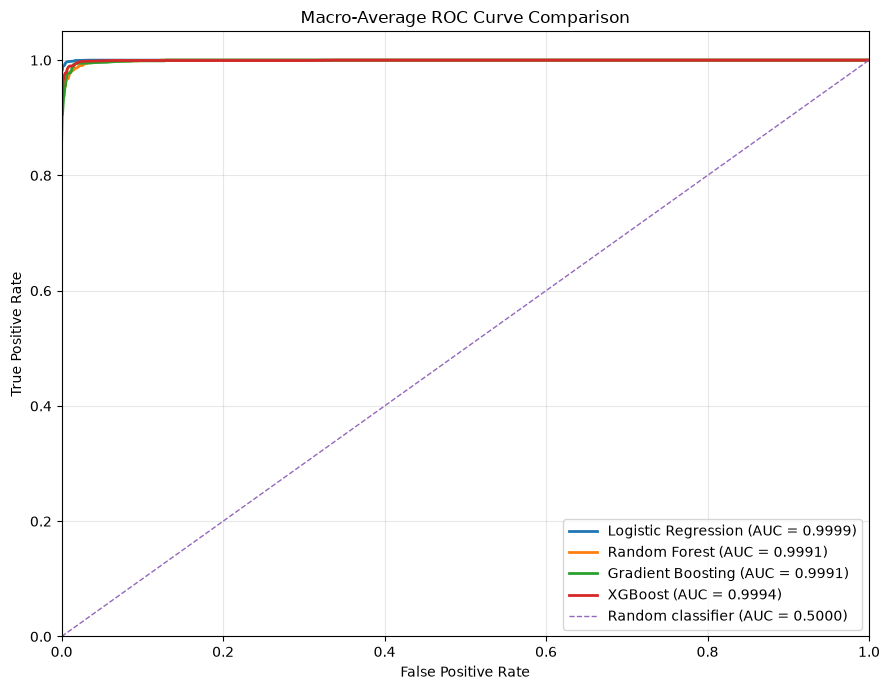

In [86]:
# ============================================================
#  COMPARE MACRO-AVERAGE ROC CURVES OF ALL MODELS
# ============================================================
# This plot displays one macro-average ROC curve for each
# trained model.
#
# Unlike the previous figures, this graph compares all models
# directly in the same figure.

plt.figure(
    figsize=(9, 7)
)

macro_roc_auc_summary = []

for model_name, trained_model in trained_models.items():

    # Predict class probabilities
    y_test_probability = trained_model.predict_proba(
        X_test
    )

    model_false_positive_rates = {}
    model_true_positive_rates = {}

    # Calculate ROC curve for every class
    for class_index in range(
        len(CLASS_LABELS)
    ):

        model_false_positive_rates[class_index], \
        model_true_positive_rates[class_index], _ = roc_curve(
            y_test_binarized[:, class_index],
            y_test_probability[:, class_index]
        )

    # Combine all false-positive-rate values
    combined_false_positive_rates = np.unique(
        np.concatenate(
            [
                model_false_positive_rates[class_index]
                for class_index in range(
                    len(CLASS_LABELS)
                )
            ]
        )
    )

    # Interpolate and average true-positive rates
    average_true_positive_rate = np.zeros_like(
        combined_false_positive_rates
    )

    for class_index in range(
        len(CLASS_LABELS)
    ):

        average_true_positive_rate += np.interp(
            combined_false_positive_rates,
            model_false_positive_rates[class_index],
            model_true_positive_rates[class_index]
        )

    average_true_positive_rate /= len(
        CLASS_LABELS
    )

    model_macro_auc = auc(
        combined_false_positive_rates,
        average_true_positive_rate
    )

    macro_roc_auc_summary.append({
        "Model": model_name,
        "Macro-average AUC": model_macro_auc
    })

    plt.plot(
        combined_false_positive_rates,
        average_true_positive_rate,
        linewidth=2,
        label=(
            f"{model_name} "
            f"(AUC = {model_macro_auc:.4f})"
        )
    )

# Random-classifier reference line
plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    linewidth=1,
    label="Random classifier (AUC = 0.5000)"
)

plt.title(
    "Macro-Average ROC Curve Comparison"
)

plt.xlabel(
    "False Positive Rate"
)

plt.ylabel(
    "True Positive Rate"
)

plt.xlim(
    0,
    1
)

plt.ylim(
    0,
    1.05
)

plt.legend(
    loc="lower right"
)

plt.grid(
    alpha=0.3
)

plt.tight_layout()
plt.show()

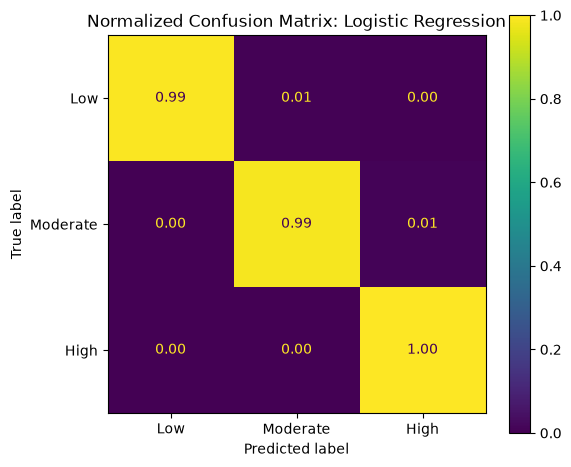

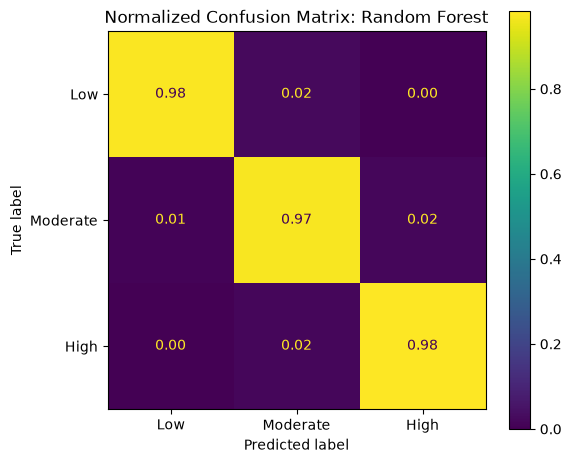

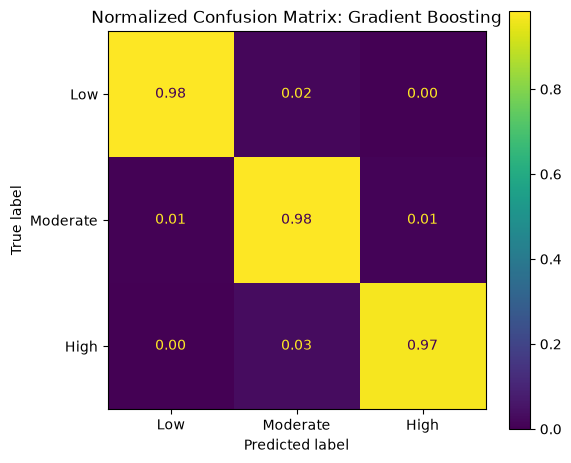

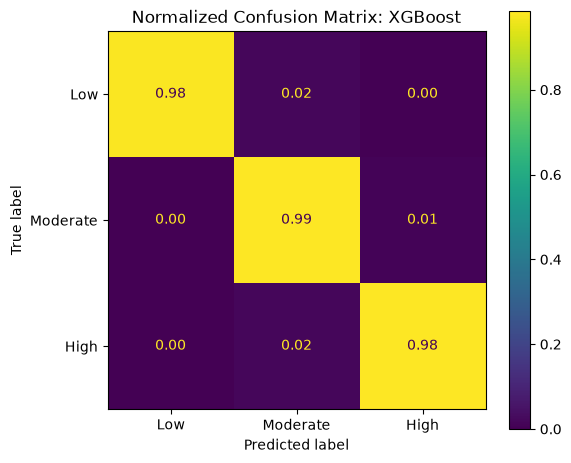

In [87]:
# ============================================================
#  DISPLAY NORMALIZED CONFUSION MATRICES
# ============================================================
# These matrices are calculated from the held-out 30% test set.
# The existing confusion matrices show the number of samples.
#
# These normalized confusion matrices show the proportion of
# each actual class that was predicted as Low, Moderate or
# High.
#
# Values on the diagonal should be close to 1.00.

for model_name, trained_model in trained_models.items():

    y_test_pred = trained_model.predict(
        X_test
    )

    normalized_confusion = confusion_matrix(
        y_test,
        y_test_pred,
        labels=CLASS_LABELS,
        normalize="true"
    )

    normalized_display = ConfusionMatrixDisplay(
        confusion_matrix=normalized_confusion,
        display_labels=CLASS_NAMES
    )

    fig, ax = plt.subplots(
        figsize=(6, 5)
    )

    normalized_display.plot(
        ax=ax,
        values_format=".2f"
    )

    ax.set_title(
        f"Normalized Confusion Matrix: {model_name}"
    )

    plt.tight_layout()
    plt.show()